# Customer Segemntation
## Intrduction

Customer Segemntation is strategical business approach to divide a broad market into smaller, more manageable groups with shared characteristics. It helps businesses understand diverse customer needs and tailor their strategies accordingly. Segmentation enables precise targeting, ensuring the right message reaches the right audience at the right time. It improves resource allocation by focusing efforts on high-potential customer groups.

This project uses a customer base data from a store. Here the customers will be divide by their purchase habit, Income and Family status. And then from the previous successful cases of each campaign we would determine which campaign should target which customer base. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')
import plotly.graph_objects as go

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, PolynomialFeatures, StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN, SpectralClustering, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import silhouette_score
import umap.umap_ as umap
from hdbscan import HDBSCAN

import optuna
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_param_importances
seed=42

In [2]:
df = pd.read_csv('marketing_campaign.csv',
                 delimiter='\t',
                 parse_dates=['Dt_Customer'],
                 date_format='%d-%m-%Y')

## EDA and Feature Engineering

In [3]:
df.shape

(2240, 29)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

Feature Engineering Steps:
- `Year_birth` column is used to determine the age of each customer and use the `Age` column for the analysis.
- `Dt_Customer` column which marks the first date when the customer begin his journey with the store is used to determine the time span for which he/she is a customer.
- `Marital_Status` column is encoded by One Hot Encoding technique
- `Education` column is encoded with Ordinal Enocding techinique with the following order<br>
  0 - Basic<br>
  1 - Graduation<br>
  2 - 2n Cycle<br>
  3 - Master<br>
  4 - PhD<br>

In the end a subset of original dataframe is used with relavant features for clustering.

In [5]:
df.Dt_Customer.max()

Timestamp('2014-06-29 00:00:00')

In [6]:
df['Age'] = 2015-df.Year_Birth

In [7]:
df['customer_for'] = (df.Dt_Customer.max() - df.Dt_Customer).dt.days

In [8]:
value_vars = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
melt_df = df.melt(id_vars =df.columns.drop(value_vars),value_vars=value_vars)
melt_df = melt_df[melt_df.value==1]

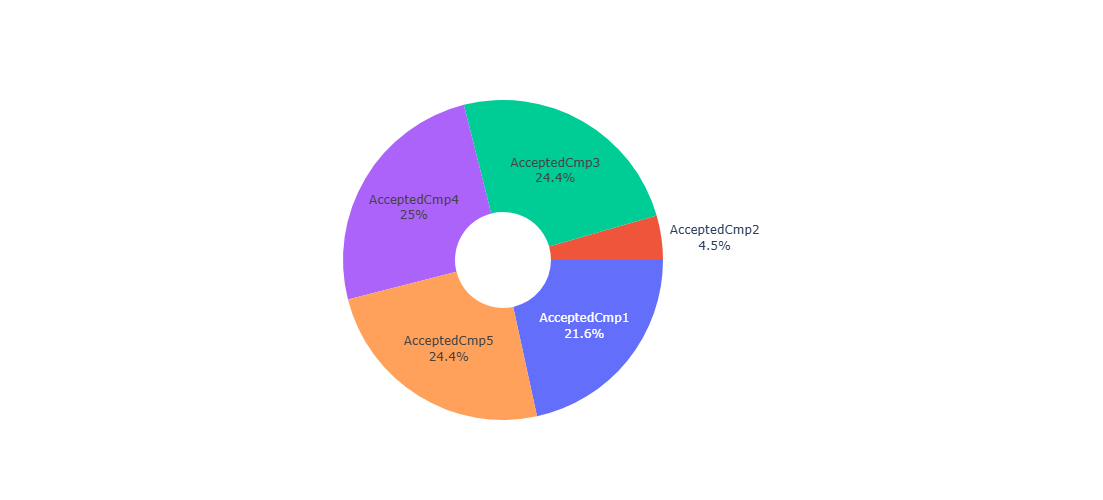

In [9]:
cmp_cnt =   melt_df.variable.value_counts().reset_index().sort_values(by='variable')
fig = go.Figure(data=[go.Pie(labels=cmp_cnt['variable'],values=cmp_cnt['count'],hole=0.3,textinfo='label+percent',showlegend=False)])
fig.update_layout(width=1000,height=500)
fig.update_traces(sort=False,rotation=90)
fig.show()

In [10]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
customer_for            0
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
# Relevant Features
rel_feat = ['Income','Kidhome','Teenhome','Recency','MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds',
             'NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth','Age', 'customer_for','Complain']

In [13]:
# sns.pairplot(sub_df)

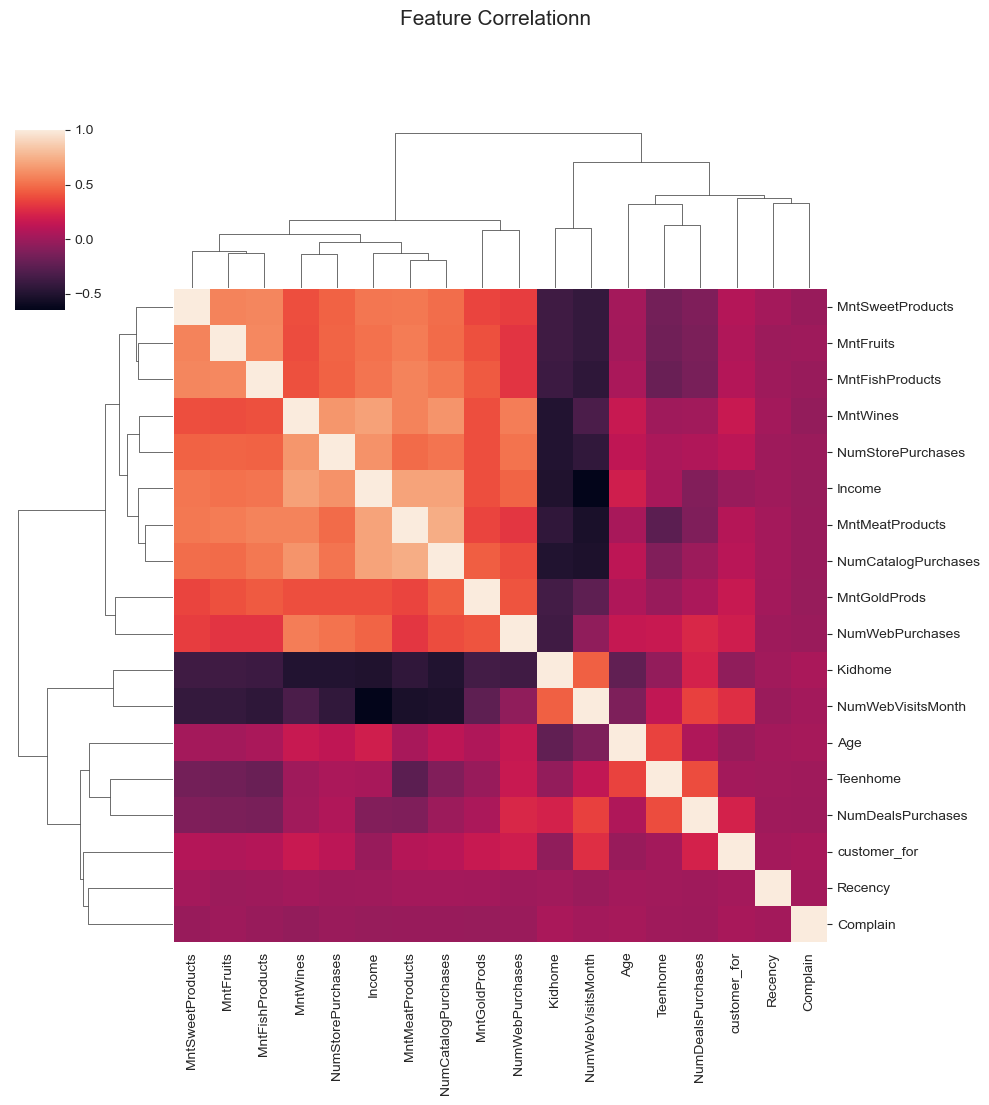

In [178]:
sns.clustermap(df[rel_feat].corr())
plt.suptitle('Feature Correlationn',y=1.1,size=15)
plt.savefig('images/correlation.png')
plt.show()

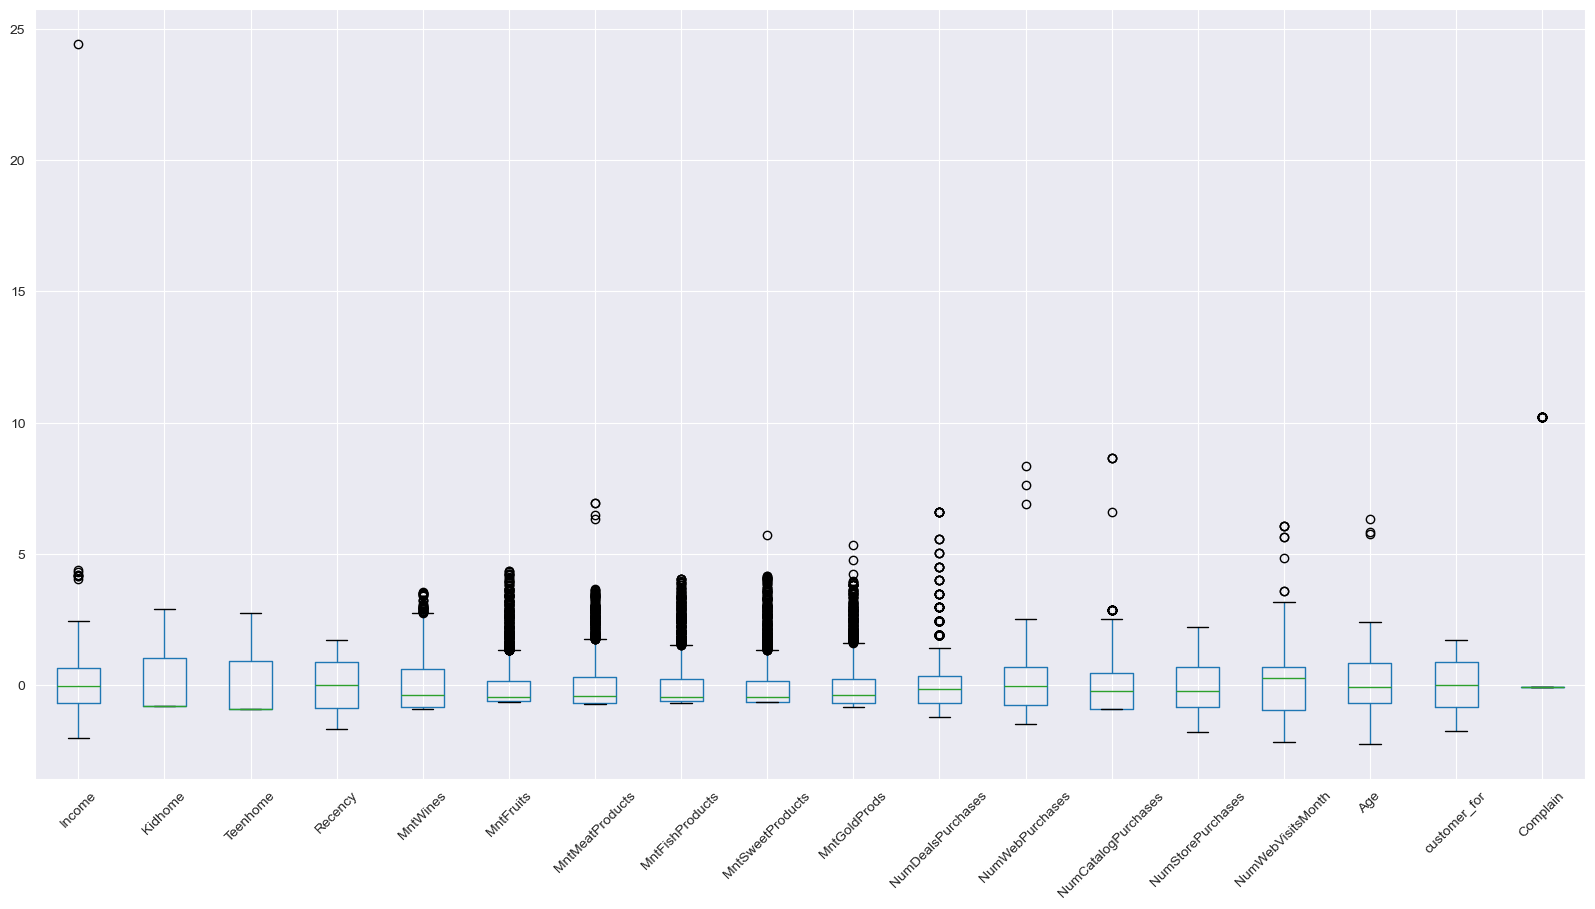

In [15]:
plt.figure(figsize=(20,10))
box = StandardScaler().set_output(transform='pandas').fit_transform(df[rel_feat]).boxplot()
plt.xticks(rotation=45)
plt.show()

Income column has an outlier that is most probably artificial as it was generated by used input. Except Kidhome and Teenhome all the other feature are generated by customer purachase behaviour. The outliers in these columns are valuable inoformation indicating anomaly.

In [16]:
df.drop(df.Income.idxmax(),inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_22440\3020196864.py:7: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



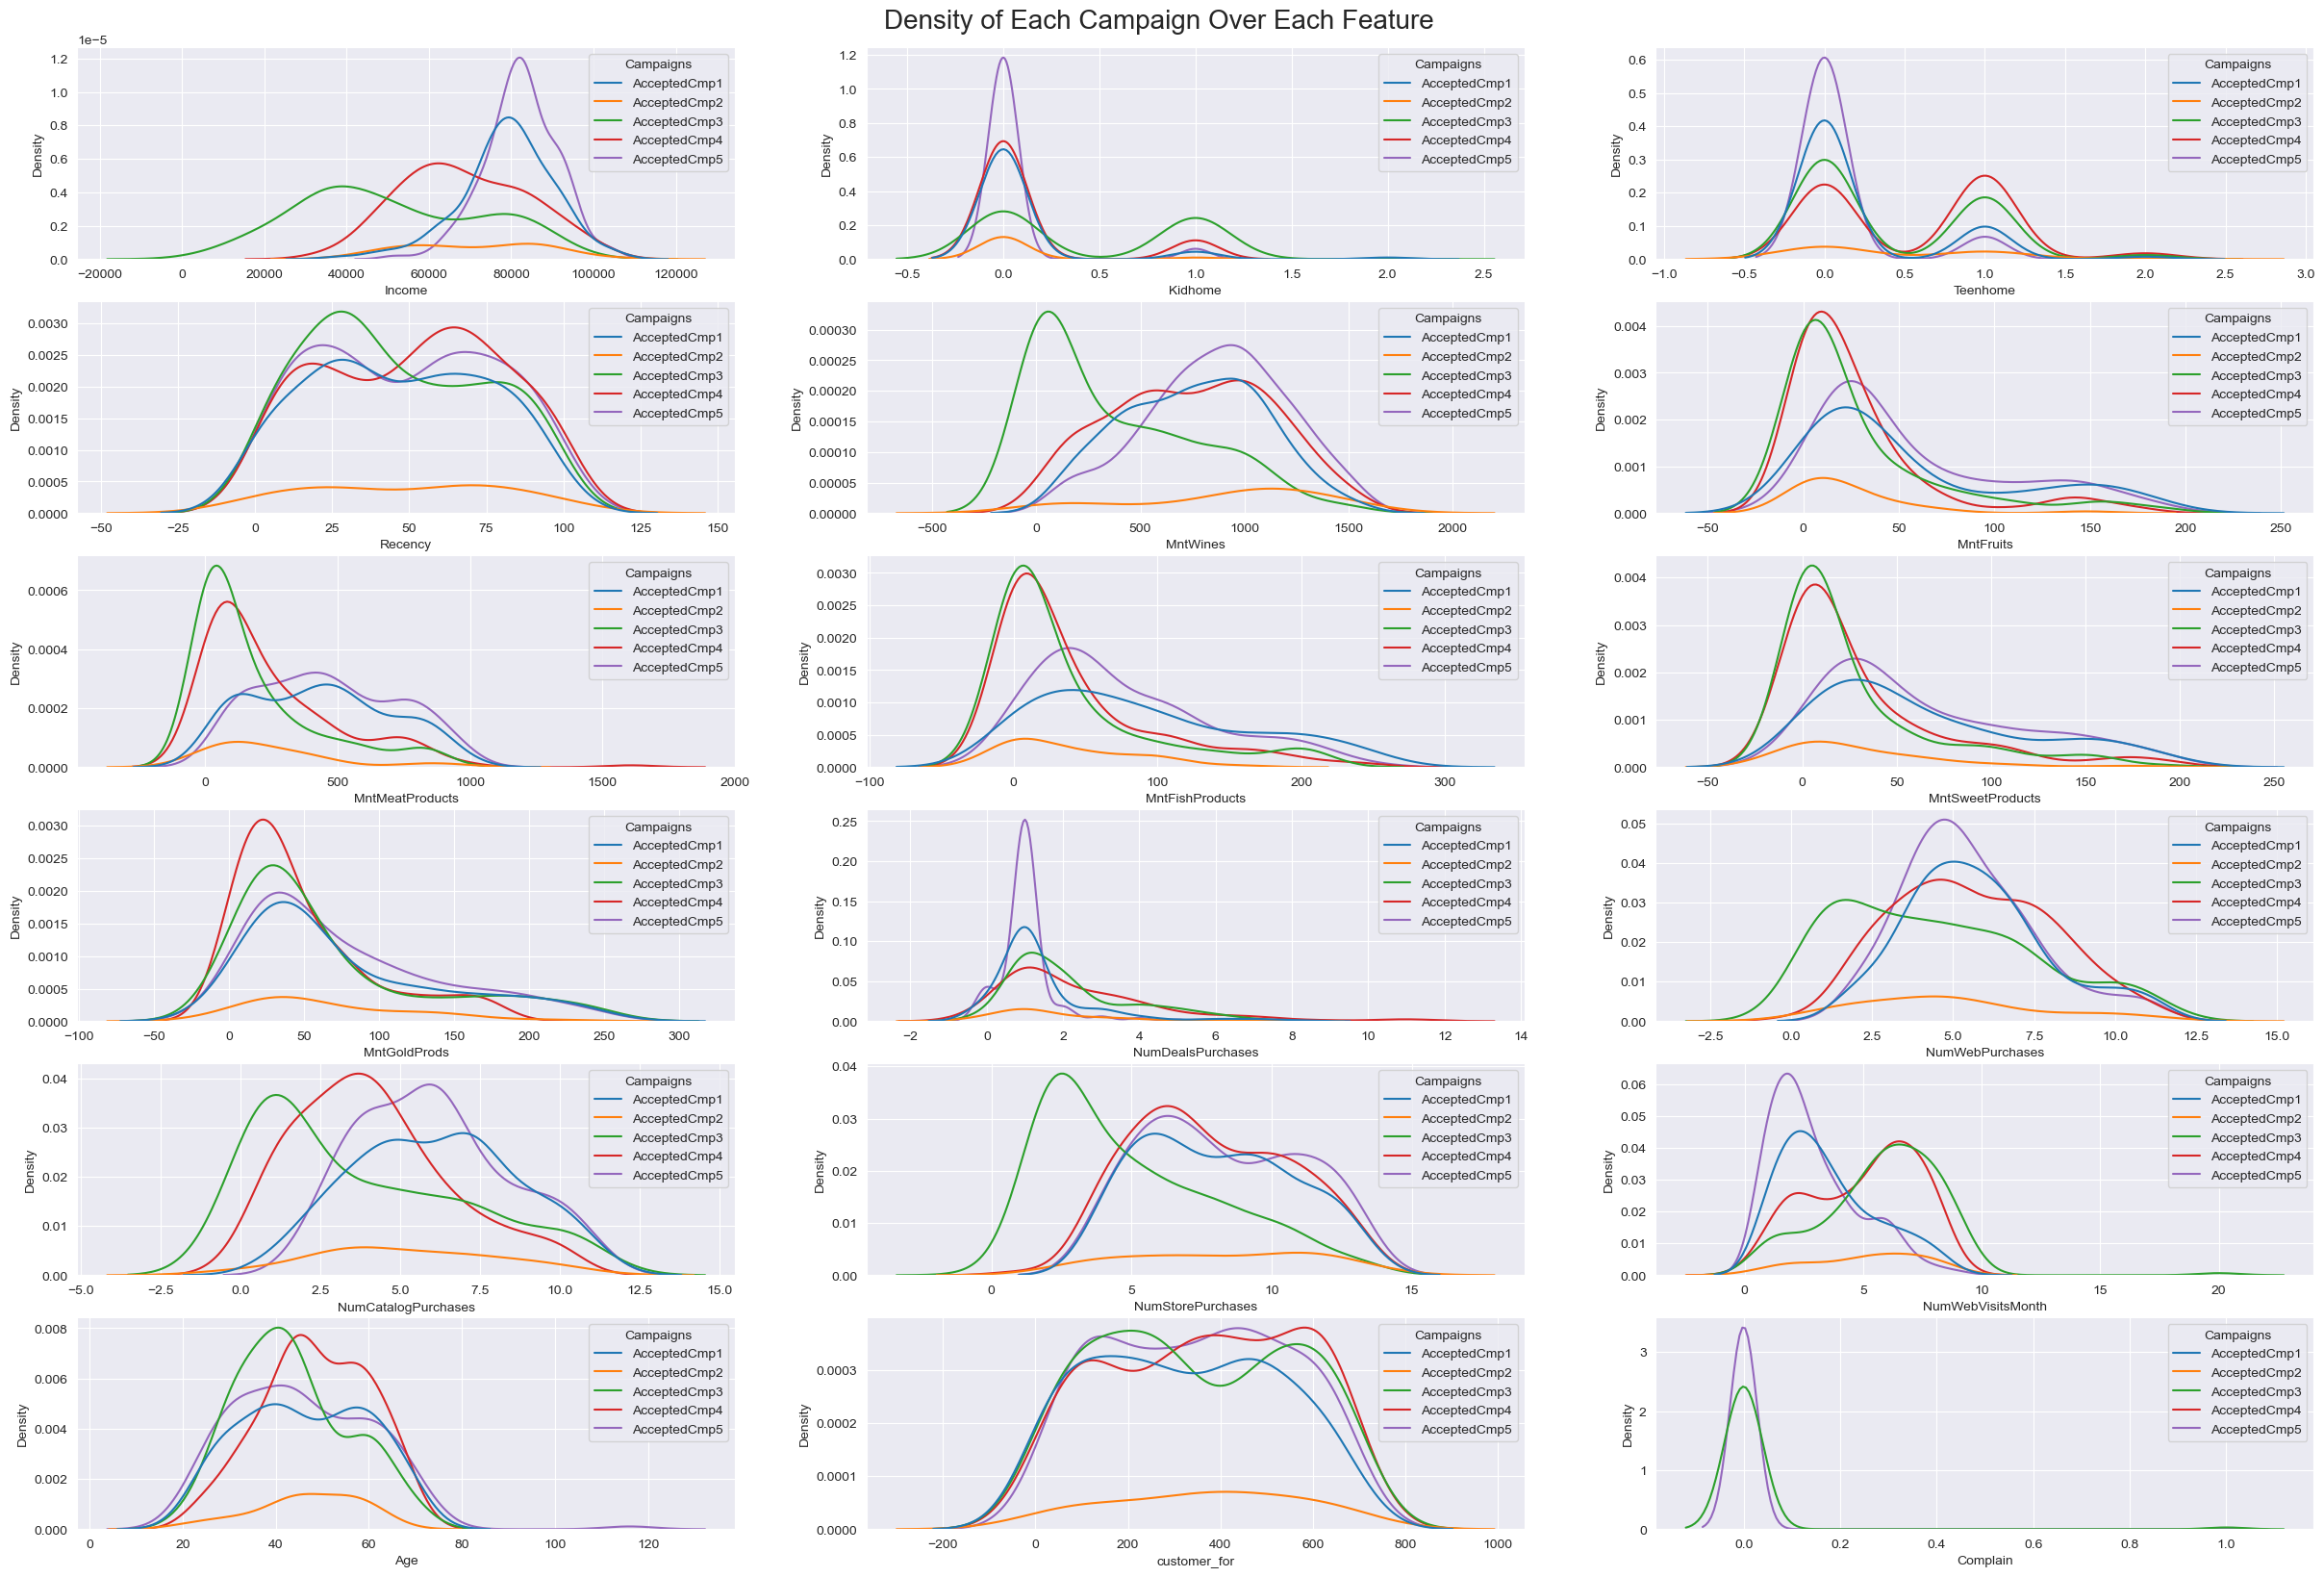

In [186]:
fig, axes = plt.subplots(6,3,figsize=(30,20))

axes = axes.flatten()

for i in range(18):
    ax = axes[i]
    sns.kdeplot(data = melt_df,x=rel_feat[i],hue='variable',ax=ax)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend_.set_title('Campaigns')
plt.suptitle('Density of Each Campaign Over Each Feature',size=20,y=0.9)
plt.savefig('images/campaigns_over_features_kde.png')
plt.show()

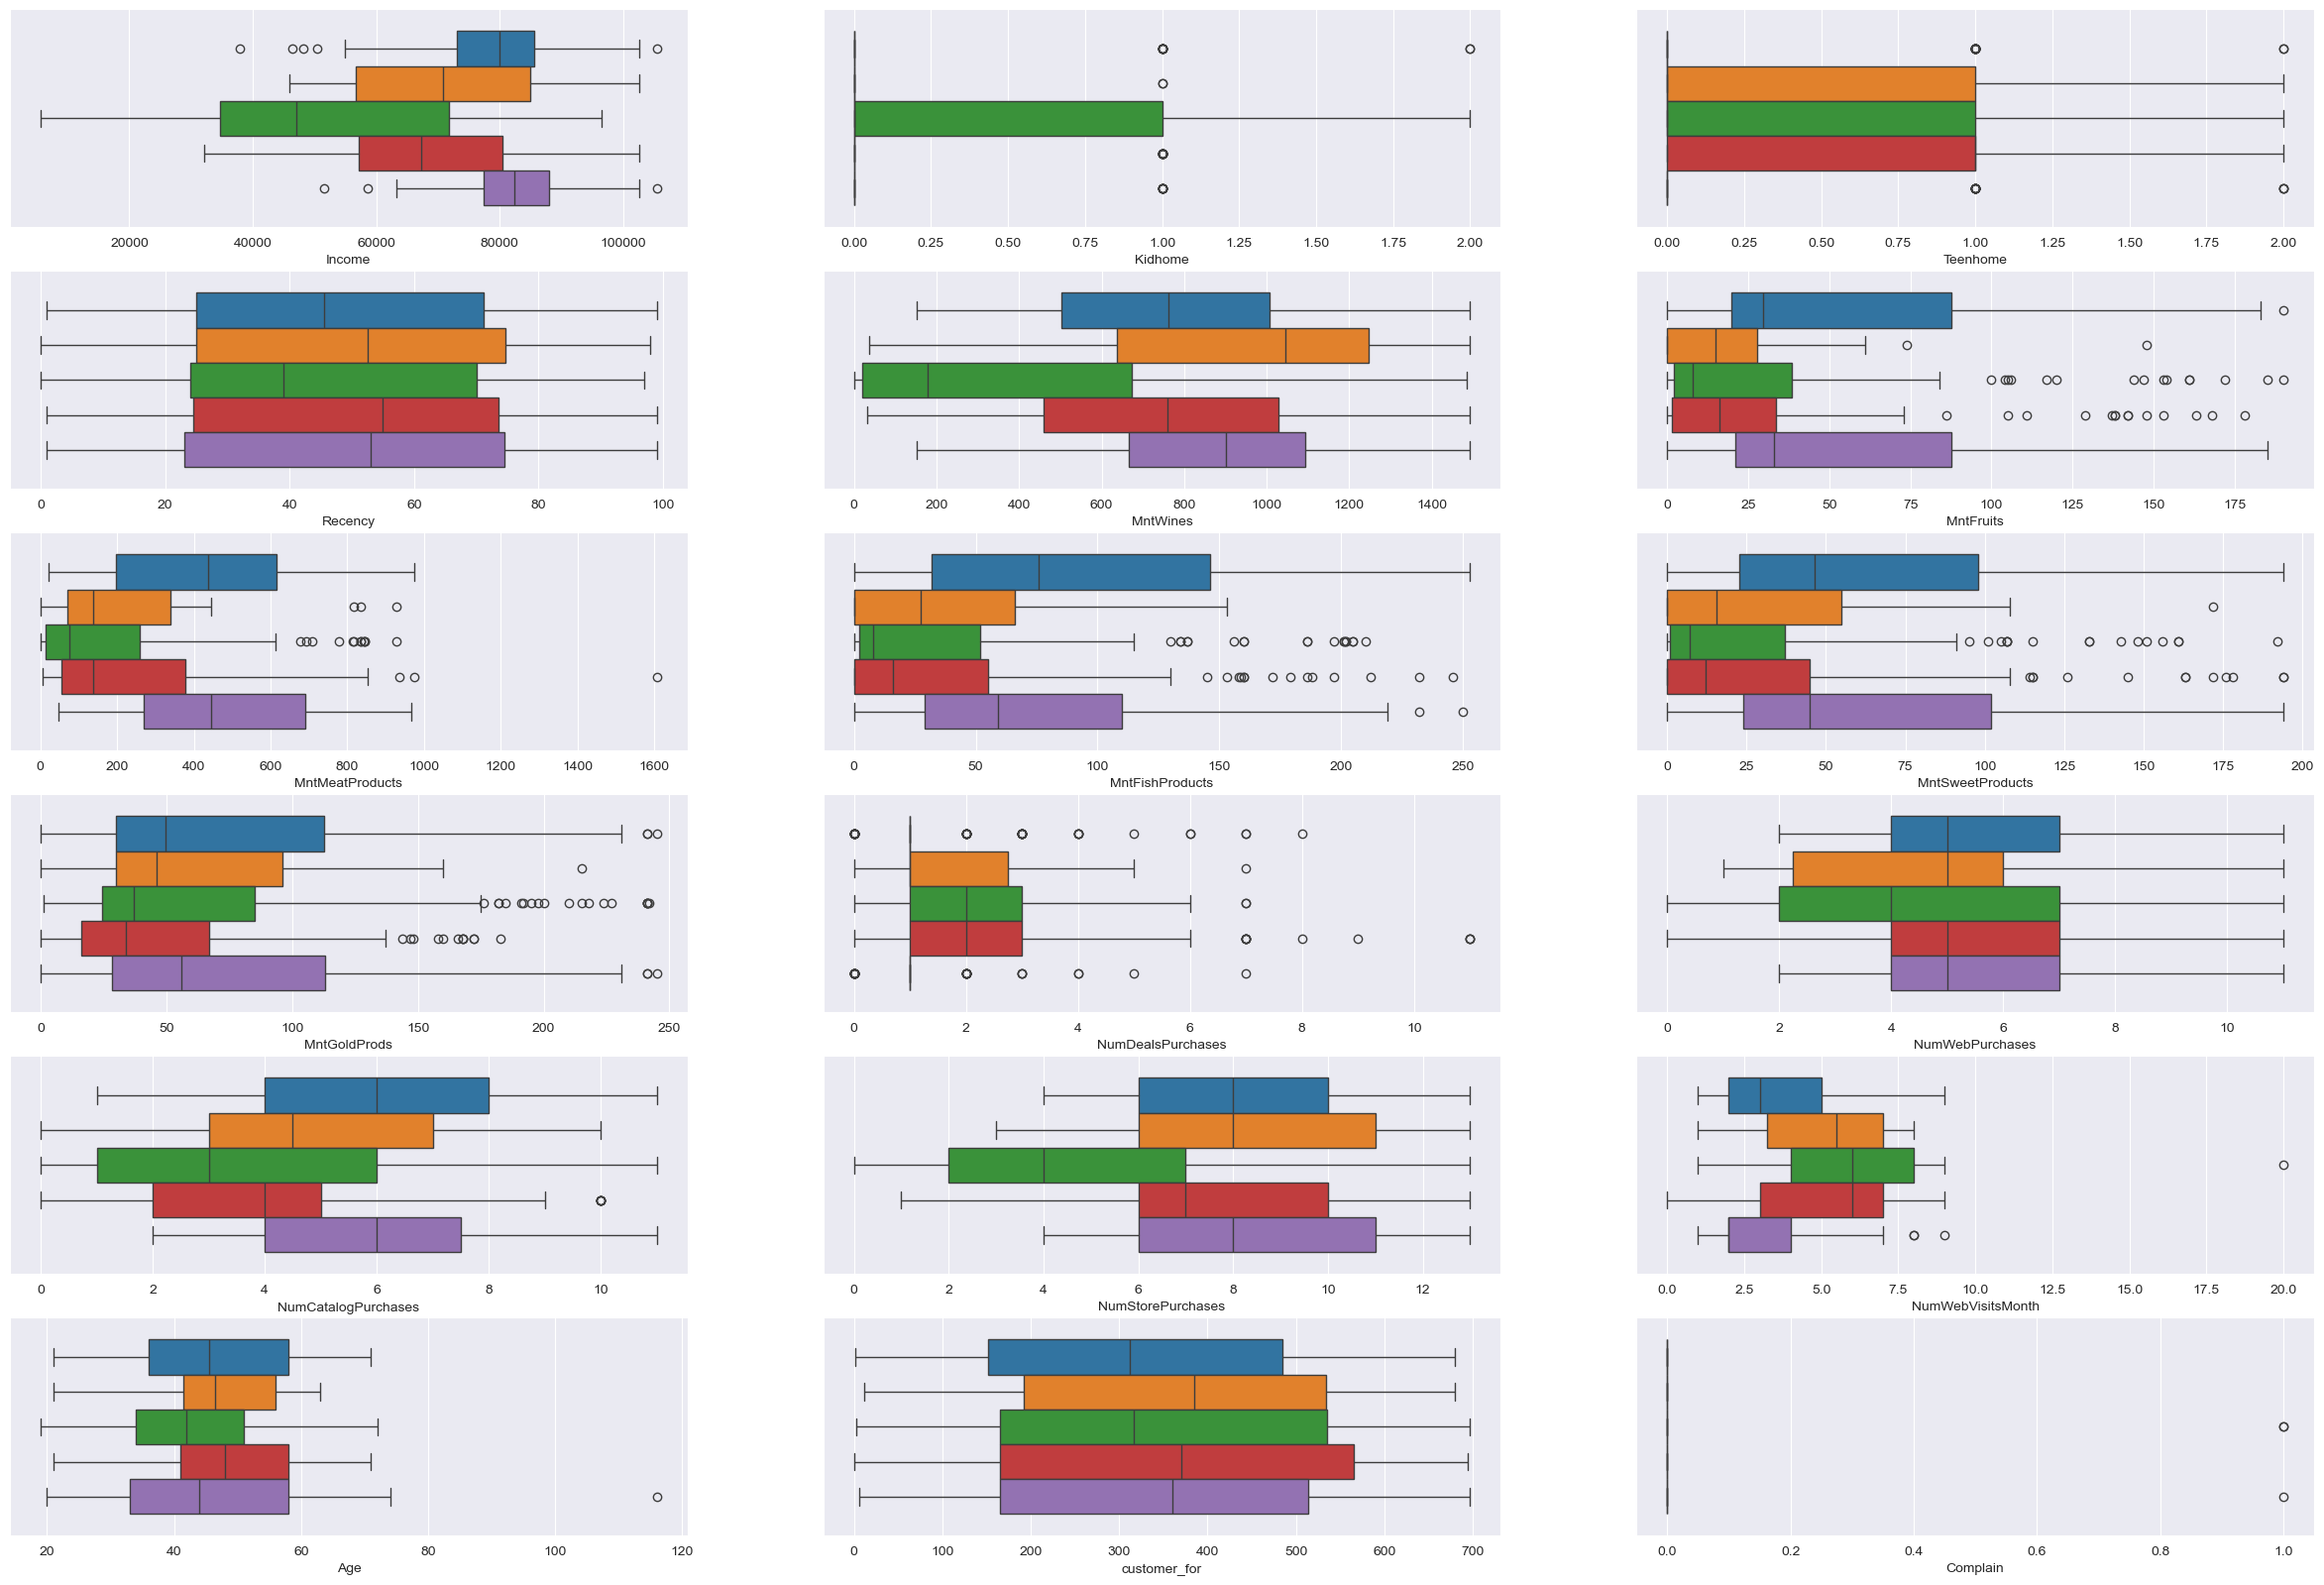

In [187]:
fig, axes = plt.subplots(6,3,figsize=(30,20))

axes = axes.flatten()

for i in range(18):
    ax = axes[i]
    sns.boxplot(data = melt_df,x=rel_feat[i],hue='variable',ax=ax)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend_.remove()
plt.savefig('images/campaigns_over_features_box.png')
plt.show()

Campaign 1 and 5 seems to successfully have targeted high income customers. These Customers are generally does not have any kids or teens home and are regualr buyers. These group of people usually dont buys any deals and are active in all platforms. They do not visit the web without buying anythin meaning they trust the store. these group of people are between 40-55 years old.

Campaign 3 seems to be attract a group with relatively low income who has kids and teens in home. They dont buy often but they frequently visits the web page and often buys deals. And age group similar to the customers accepting campaign 1 and 5. They prefers buying from online but still a lot less active than the previous group. 

Campaign 4 was responded by a group of people who have moderate income and doesnt have kids at home but has teens. Buys oftern more than 2nd group and but a lot less than 1st group. Frequently visits web and buys deal. They are also active in all platforms.

Campaign 2 has a very low customer base attracted either it was not a very good campaign or it ran for short time. But even in this short time it seems to attract people that were succefully converted by campaign 3.

C:\Users\ACER\AppData\Local\Temp\ipykernel_22440\303264626.py:7: UserWarning:

The palette list has more values (10) than needed (8), which may not be intended.



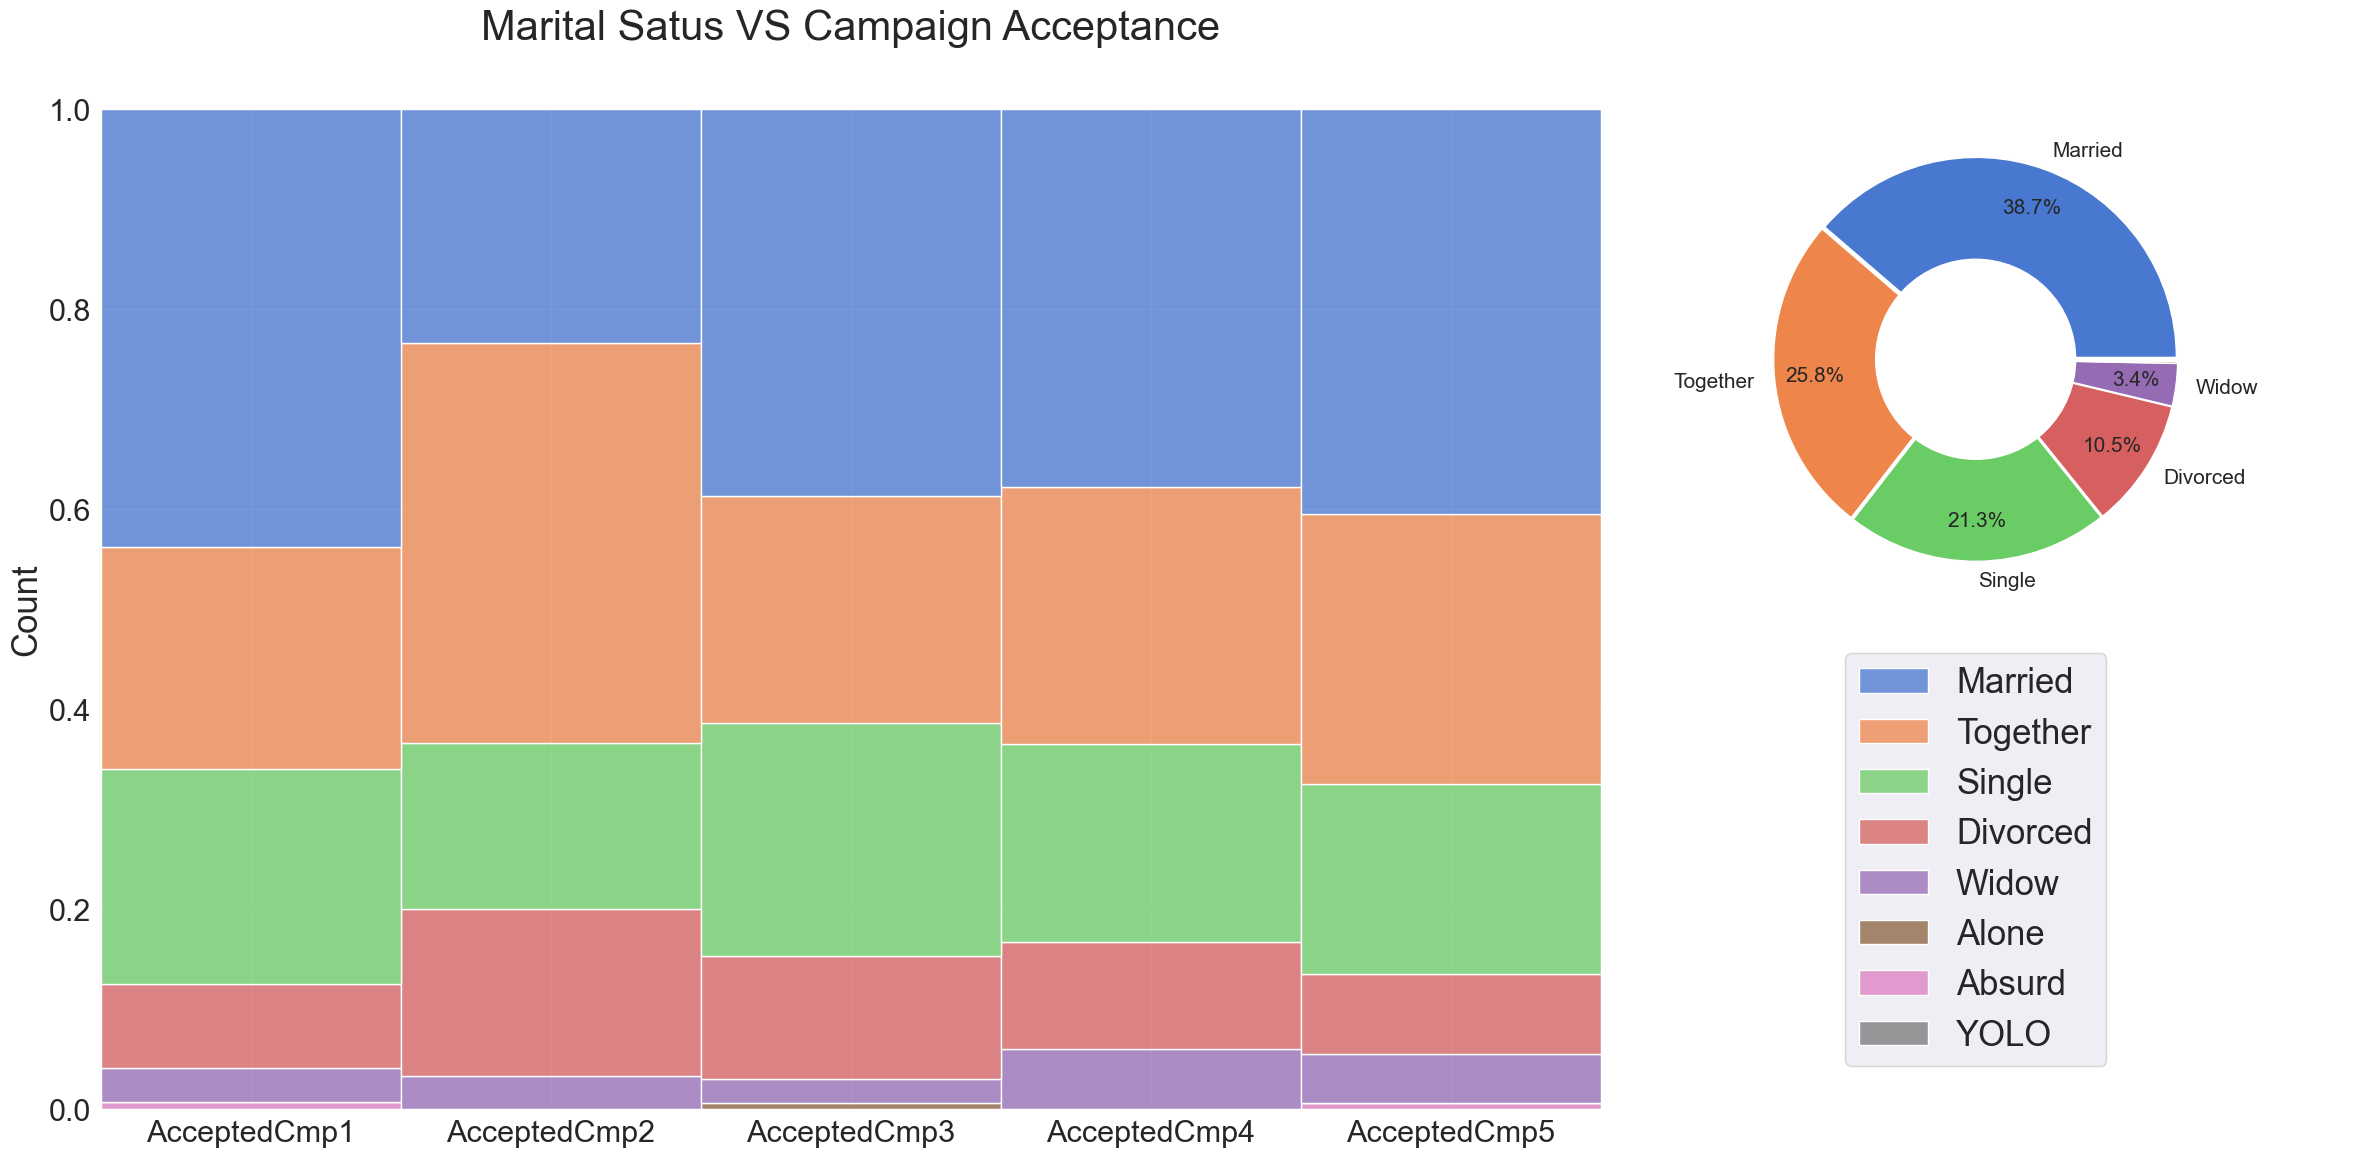

In [192]:
ms = df.Marital_Status.value_counts(normalize=True)

fig = plt.figure(figsize=(15,10))

# Histogram
hist = fig.add_axes([0,.25,1,1])
sns.histplot(melt_df,
             x='variable',
             hue='Marital_Status',
             multiple='fill',
             hue_order=ms.index,
             palette=sns.color_palette('muted'))
hist.tick_params(axis='both',labelsize=22,rotation=0)
hist.set_xlabel('',fontsize=25,labelpad=20)
hist.set_ylabel(hist.get_ylabel(),fontsize=25)

#Legend
legend_ax = fig.add_axes([1,0.25,.5,.5])
legend = hist.legend_
legend_ax.legend(legend.legend_handles, [text.get_text() for text in legend.get_texts()], 
                 loc='center',fontsize=25,)
legend_ax.axis('off')
hist.legend_.remove()

# Pie
pie = fig.add_axes([1,.75,0.5,0.5])
labels = [i if ms[i] > 0.01 else '' for i in ms.index]
wedges, texts, autotexts = pie.pie(ms,
                                   textprops={'size':15},
                                   autopct='%1.1f%%',
                                   pctdistance=.8,
                                   explode=[0.01]*len(ms.index),
                                   labels = labels,
                                   colors = sns.color_palette('muted')
                                  )
for i,autotext in enumerate(autotexts):
    if ms[ms.index[i]] <= 0.01:
        autotext.set_visible(False)
pie.add_artist(plt.Circle((0,0),.5,fc='white'))

plt.suptitle('Marital Satus VS Campaign Acceptance',y=1.35,fontsize=30)
fig.savefig('images/ms.png',bbox_inches='tight')
plt.show()

Marital Status of customers does not have much of an effect on a successful campaign. Every succesfull campaigns seems to get customers having similar distribution of marital status. 

In [20]:
ohe = OneHotEncoder(drop='first',sparse_output=False).set_output(transform='pandas')
ohe_ms = ohe.fit_transform(df[['Marital_Status']])

C:\Users\ACER\AppData\Local\Temp\ipykernel_22440\297453283.py:7: UserWarning:

The palette list has more values (10) than needed (5), which may not be intended.



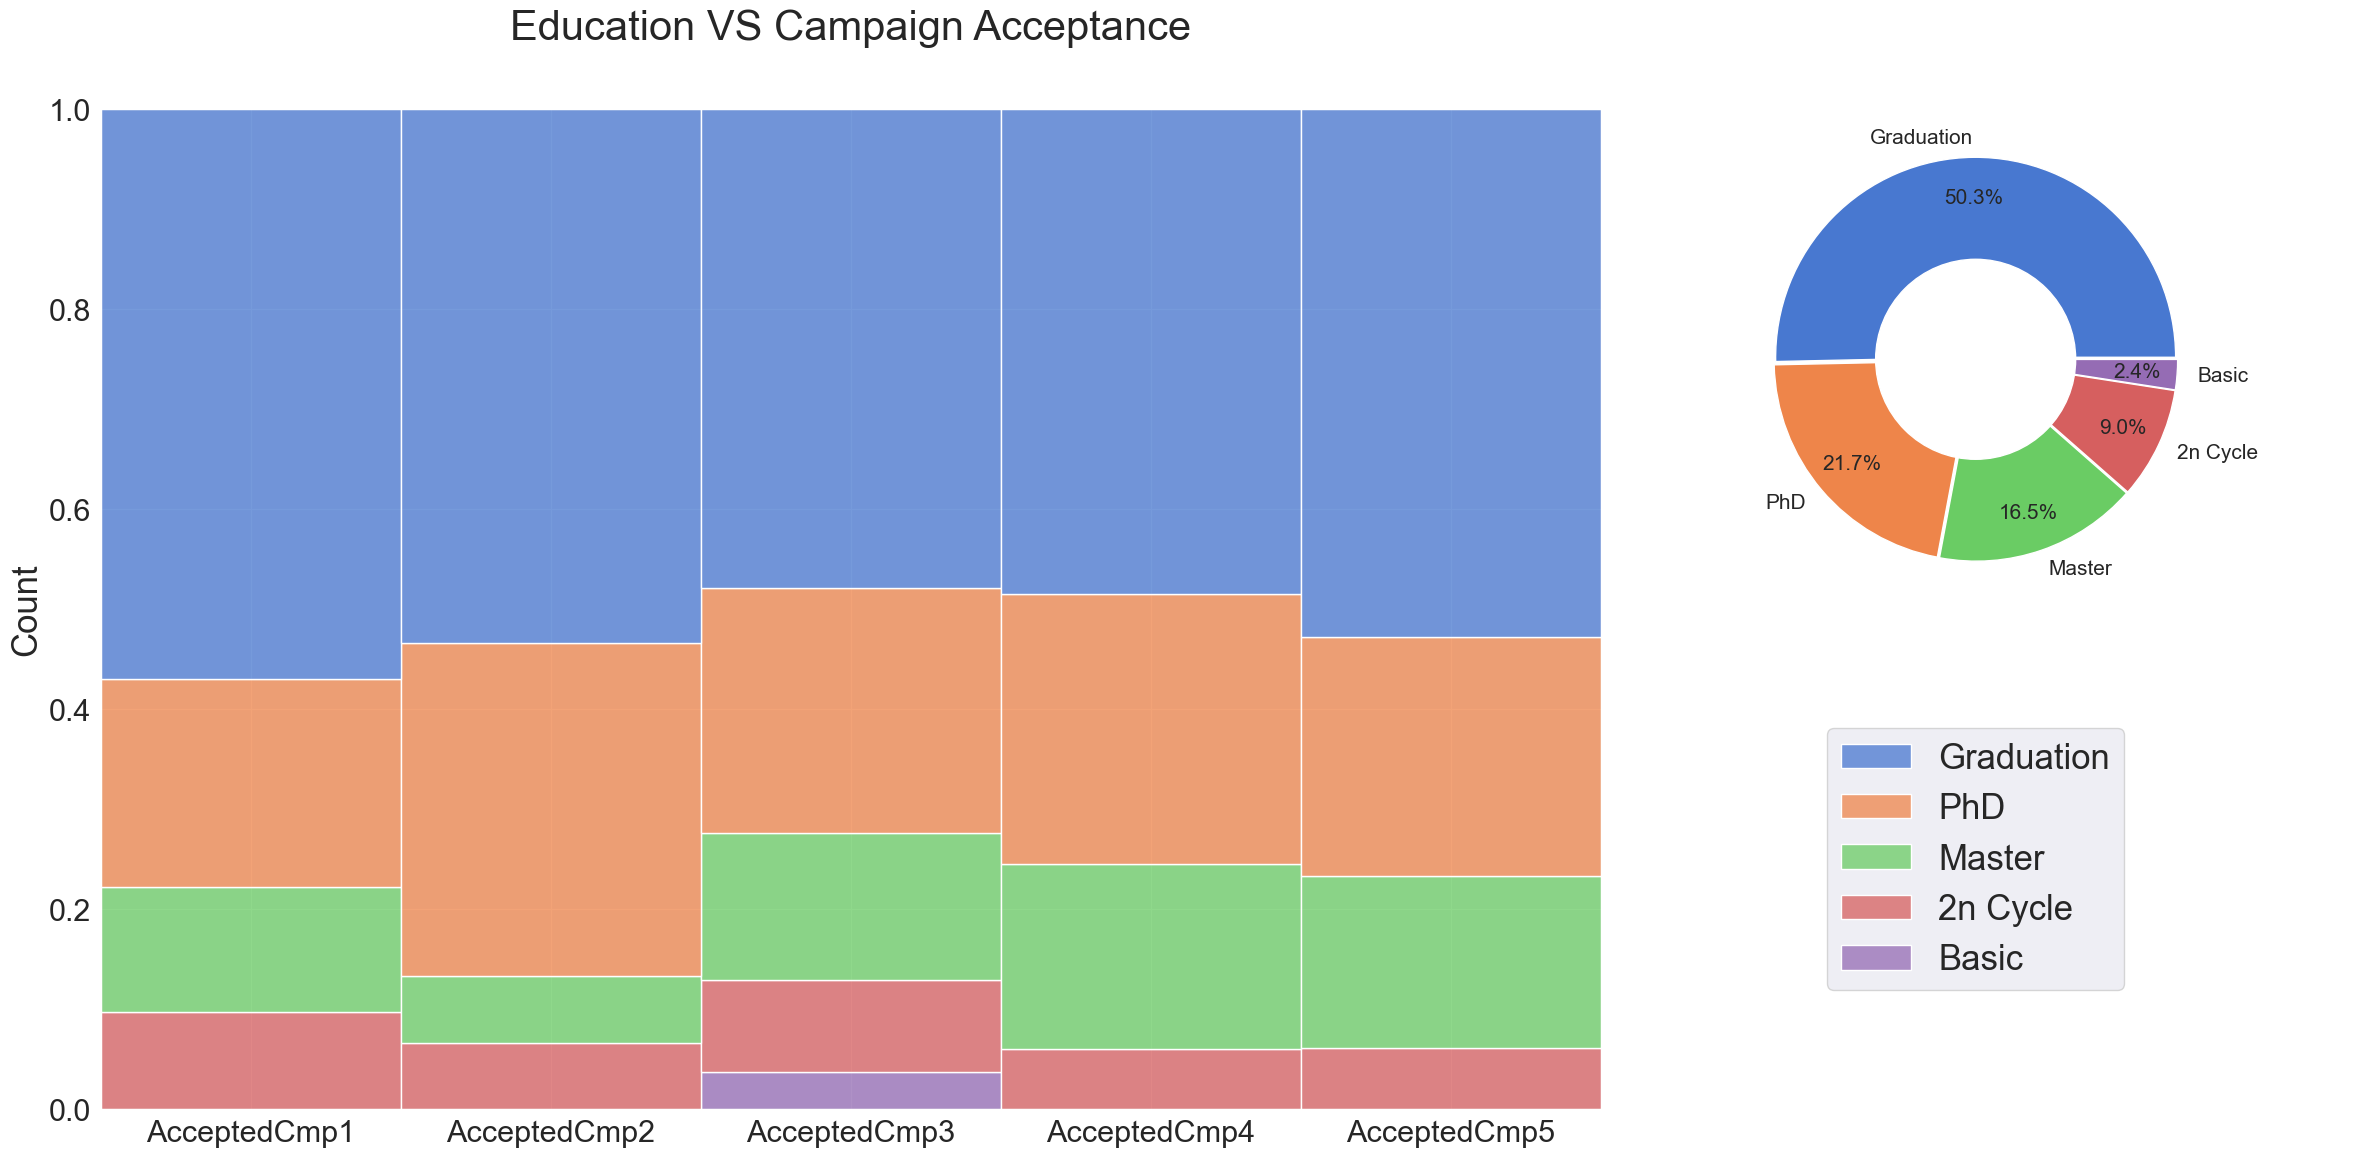

In [193]:
edu = df.Education.value_counts(normalize=True)

fig = plt.figure(figsize=(15,10))

# Histogram
hist = fig.add_axes([0,.25,1,1])
sns.histplot(melt_df,
             x='variable',
             hue='Education',
             multiple='fill',
             hue_order=edu.index,
             palette=sns.color_palette('muted'))
hist.tick_params(axis='both',labelsize=22,rotation=0)
hist.set_xlabel('',fontsize=25,labelpad=20)
hist.set_ylabel(hist.get_ylabel(),fontsize=25)

# Legend
legend_ax = fig.add_axes([1,0.25,.5,.5])
legend = hist.legend_
legend_ax.legend(legend.legend_handles, [text.get_text() for text in legend.get_texts()], 
                 loc='center',fontsize=25,)
legend_ax.axis('off')
hist.legend_.remove()

# Pie
pie = fig.add_axes([1,.75,0.5,0.5])
labels = [i if edu[i] > 0.01 else '' for i in edu.index]
wedges, texts, autotexts = pie.pie(edu,
                                   textprops={'size':15},
                                   autopct='%1.1f%%',
                                   pctdistance=.8,
                                   explode=[0.01]*len(edu.index),
                                   labels = labels,
                                   colors = sns.color_palette('muted')
                                  )
for i,autotext in enumerate(autotexts):
    if edu[edu.index[i]] <= 0.01:
        autotext.set_visible(False)
pie.add_artist(plt.Circle((0,0),.5,fc='white'))

plt.suptitle('Education VS Campaign Acceptance',y=1.35,fontsize=30)
fig.savefig('images/edu.png',bbox_inches='tight')
plt.show()

It seems like campaign 4 have a higher affinity to Masters student where more conversion of graduate student was seen in campaign 4

In [22]:
oe = OrdinalEncoder(categories=[['Basic','Graduation','2n Cycle','Master','PhD']]).set_output(transform='pandas')
oe_edu = oe.fit_transform(df[['Education']])

In [23]:
sub_df = df[rel_feat]
sub_df = pd.concat([sub_df,oe_edu,ohe_ms],axis=1)
sub_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2215 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Income                   2215 non-null   float64
 1   Kidhome                  2215 non-null   int64  
 2   Teenhome                 2215 non-null   int64  
 3   Recency                  2215 non-null   int64  
 4   MntWines                 2215 non-null   int64  
 5   MntFruits                2215 non-null   int64  
 6   MntMeatProducts          2215 non-null   int64  
 7   MntFishProducts          2215 non-null   int64  
 8   MntSweetProducts         2215 non-null   int64  
 9   MntGoldProds             2215 non-null   int64  
 10  NumDealsPurchases        2215 non-null   int64  
 11  NumWebPurchases          2215 non-null   int64  
 12  NumCatalogPurchases      2215 non-null   int64  
 13  NumStorePurchases        2215 non-null   int64  
 14  NumWebVisitsMonth        2215

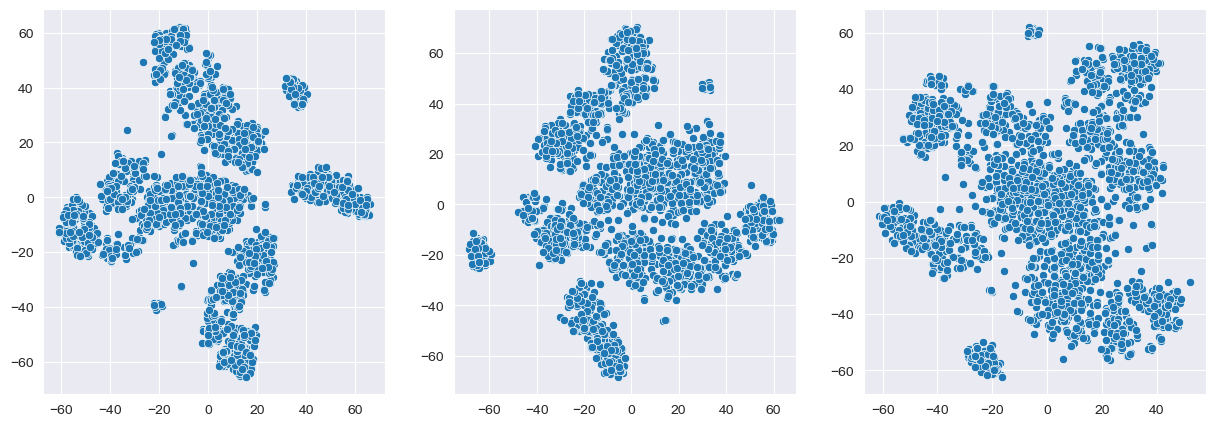

In [24]:
fig, axes = plt.subplots(1,3,figsize=(15,5))
axes = axes.flatten()
for i in range(1,4):
    ss = StandardScaler().set_output(transform='pandas')
    poly = PolynomialFeatures(degree=i)
    ss_sub_df = ss.fit_transform(sub_df)
    poly_sub_df = poly.fit_transform(ss_sub_df)
    tsne = TSNE()
    poly_reduced=tsne.fit_transform(poly_sub_df)
    sns.scatterplot(x=poly_reduced[:,0],y=poly_reduced[:,1],ax=axes[i-1])

C:\Users\ACER\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

C:\Users\ACER\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

C:\Users\ACER\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



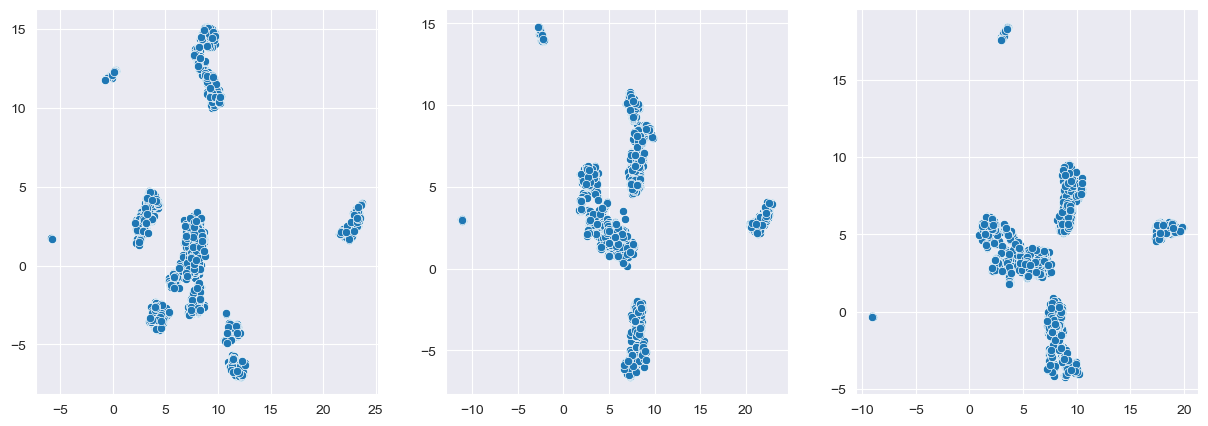

In [25]:


poly_2dim = []

for i in range(1,4):
    ss = StandardScaler().set_output(transform='pandas')
    poly = PolynomialFeatures(degree=i)
    ss_sub_df = ss.fit_transform(sub_df)
    poly_sub_df = poly.fit_transform(ss_sub_df)
    um = umap.UMAP(random_state=seed)
    poly_reduced=um.fit_transform( poly_sub_df)
    poly_2dim.append(poly_reduced)
    # sns.scatterplot(x=poly_reduced[:,0],y=poly_reduced[:,1],ax=axes[i-1])

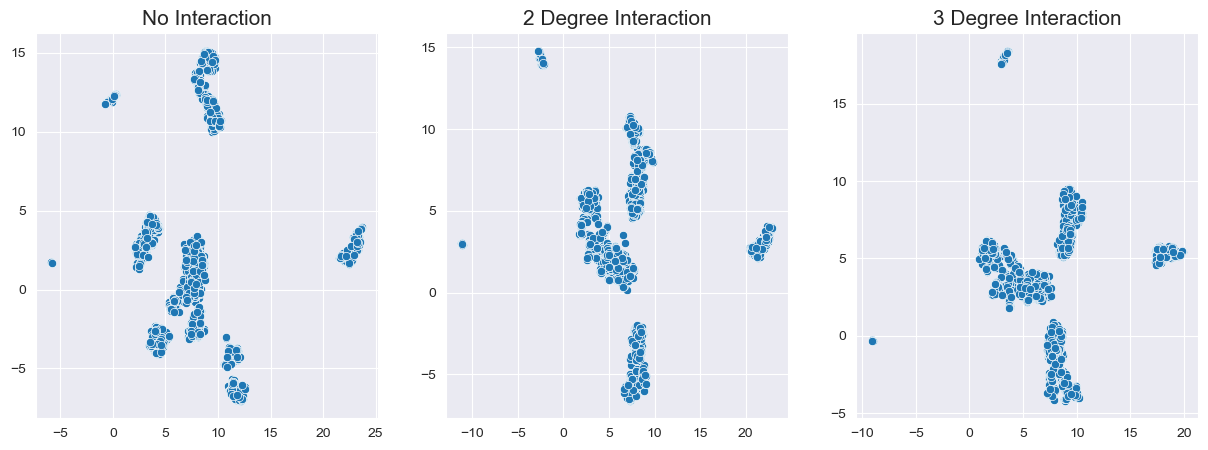

In [198]:
fig, axes = plt.subplots(1,3,figsize=(15,5))
axes = axes.flatten()

for i in range(3):
    sct = sns.scatterplot(x=poly_2dim[i][:,0],y=poly_2dim[i][:,1],ax=axes[i])
    if i == 0:
        sct.set_title('No Interaction',fontsize=15)
    else:
        sct.set_title(f'{i+1} Degree Interaction',fontsize=15) 
# plt.suptitle('Uniform Mainfold Approximation and Projection of Features with Different Degree of Interaction,fontsize=20)
plt.savefig('images/plain_umap.png')
plt.show()

At least 10 groups are visible from this TSNE and UMAP graphs with upto cubic inetraction. 

## Clustering

### Helper Functions

In [26]:
def cluster(model,model_params,n_trials=30):
    def objective(trial):
        params = model_params(trial)
        model.set_params(**params)
        labels = model.fit_predict(sub_df)
        score = silhouette_score(model.named_steps['umap'].embedding_,labels)
        return score

    study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective,n_trials=n_trials)

    model = model.set_params(**study.best_trial.params)

    return study, model

In [27]:
def visualize(study):
    plot_optimization_history(study).show()
    plot_parallel_coordinate(study).show()
    plot_param_importances(study).show()
    

In [28]:
# poly_2dim = []
# for i in range(1,4):
#     ss = StandardScaler().set_output(transform='pandas')
#     poly = PolynomialFeatures(degree=i)
#     ss_sub_df = ss.fit_transform(sub_df)
#     poly_sub_df = poly.fit_transform(ss_sub_df)
#     um = umap.UMAP(random_state=seed)
#     poly_reduced=um.fit_transform( poly_sub_df)
#     poly_2dim.append(poly_reduced)

C:\Users\ACER\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

C:\Users\ACER\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

C:\Users\ACER\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [199]:
def summary(labels,title):
    fig, axes = plt.subplots(1,3,figsize=(21,7))
    axes = axes.flatten()
    for i in range(3):
        sct = sns.scatterplot(x=poly_2dim[i][:,0],y=poly_2dim[i][:,1],hue=labels,ax=axes[i],
                              palette=sns.color_palette('tab20',n_colors=len(np.unique(labels))))
        sct.legend_.set_title('Clusters')
        sct.legend(loc='lower left')
        if i == 0:
            sct.set_title('No Interaction',fontsize=15)
        else:
            sct.set_title(f'{i+1} Degree Interaction',fontsize=15) 
    plt.suptitle(title,fontsize=20)
    plt.savefig(f'images/{title} proj.png')
    
    campaigns = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
    cmp_lab = pd.concat([df[campaigns],pd.DataFrame({'cluster':labels},index=df.index)],axis=1)
    cmp_lab['AcceptedNone'] = (~cmp_lab[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']].any(axis=1)).astype(int)
    cnt = cmp_lab.groupby('cluster').sum()
    cnt = cnt.iloc[:,:5]/cnt.sum(axis=1).values.reshape(-1,1)
    sns.clustermap(cnt,annot=True,cmap='vlag')
    plt.savefig(f'images/{title} hm.png')
    
    suggestion = {}
    for c in range(len(cnt.columns)):
        suggestion[f'Campaign {c+1}'] = cnt.index[cnt.iloc[:,c] >= .1].to_list()
    
    return suggestion

### HDBSCAN

In [35]:
hdb_pipe = Pipeline([
    ('ss1',StandardScaler().set_output(transform='pandas')),
    ('poly',PolynomialFeatures().set_output(transform='pandas')),
    ('umap',umap.UMAP(random_state=seed)),
    ('hdb',HDBSCAN(gen_min_span_tree=True))
])

def objective(trial):
        params = {
            'poly__degree': trial.suggest_int('poly__degree',1,2),
            'umap__n_neighbors': trial.suggest_int('umap__n_neighbors', 5, 50),
            'umap__n_components': trial.suggest_int('umap__n_components', 2, 10),
            'umap__min_dist': trial.suggest_float('umap__min_dist', 0.01, 0.99),
            'umap__metric': trial.suggest_categorical('umap__metric', ['euclidean','cosine']),
            'hdb__min_cluster_size': trial.suggest_int("hdb__min_cluster_size", 5, 50),
            'hdb__min_samples': trial.suggest_int('hdb__min_samples', 3, 20),
            # 'hdb__cluster_selection_epsilon': trial.suggest_float('hdb__cluster_selection_epsilon', 0, 1.0),
            
        }

        hdb_pipe = hdb_pipe = Pipeline([
            ('ss1',StandardScaler().set_output(transform='pandas')),
            ('poly',PolynomialFeatures().set_output(transform='pandas')),
            ('umap',umap.UMAP(random_state=seed)),
            ('hdb',HDBSCAN(gen_min_span_tree=True))
        ])
        clusterer = hdb_pipe.set_params(**params).fit(sub_df)
        labels = clusterer.named_steps['hdb'].labels_

        if len(set(labels)) < 12:  
            return -1.0
        
        return clusterer.named_steps['hdb'].relative_validity_  

hdb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=seed))
hdb_study.optimize(objective,n_trials=30)

[I 2025-04-20 18:32:40,895] A new study created in memory with name: no-name-1c10c29e-d20b-4712-9ef6-5deff039ff38
C:\Users\ACER\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

[I 2025-04-20 18:32:48,127] Trial 0 finished with value: -1.0 and parameters: {'poly__degree': 1, 'umap__n_neighbors': 48, 'umap__n_components': 8, 'umap__min_dist': 0.5966853145130959, 'umap__metric': 'euclidean', 'hdb__min_cluster_size': 7, 'hdb__min_samples': 18}. Best is trial 0 with value: -1.0.
C:\Users\ACER\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

[I 2025-04-20 18:32:54,509] Trial 1 finished with value: -1.0 and parameters: {'poly__degree': 2, 'umap__n_neighbors': 37, 'umap__n_components': 2, 'umap__min_dist': 0.9605116551187545, 'umap__metric': 'euclidean', 'hdb__min_cluster_size': 13, 'hdb__min_sample

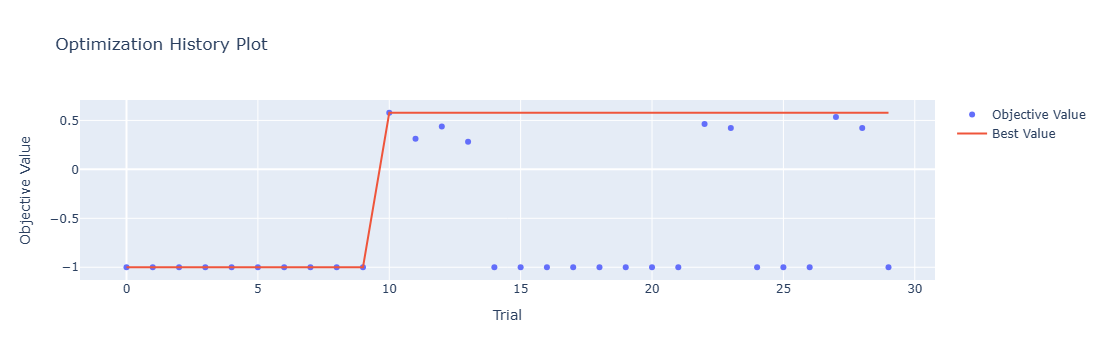

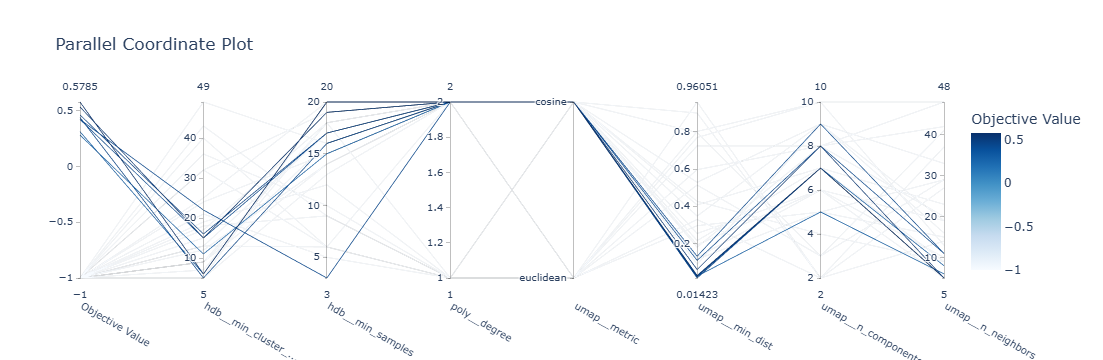

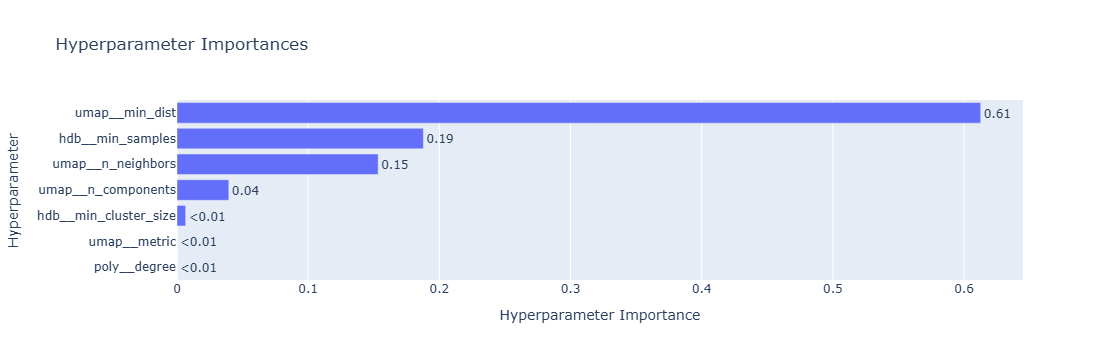

In [32]:
visualize(hdb_study)

In [201]:
hdb_study.best_trial.value

0.5784539843238417

In [33]:
hdb_study.best_trial.params

{'poly__degree': 2,
 'umap__n_neighbors': 5,
 'umap__n_components': 7,
 'umap__min_dist': 0.02760263810252339,
 'umap__metric': 'cosine',
 'hdb__min_cluster_size': 6,
 'hdb__min_samples': 20}

Campaigns and suggested clusters of HDBSCAN


{'Campaign 1': [8, 11],
 'Campaign 2': [],
 'Campaign 3': [3, 6],
 'Campaign 4': [1, 8, 9, 12],
 'Campaign 5': [8, 11]}

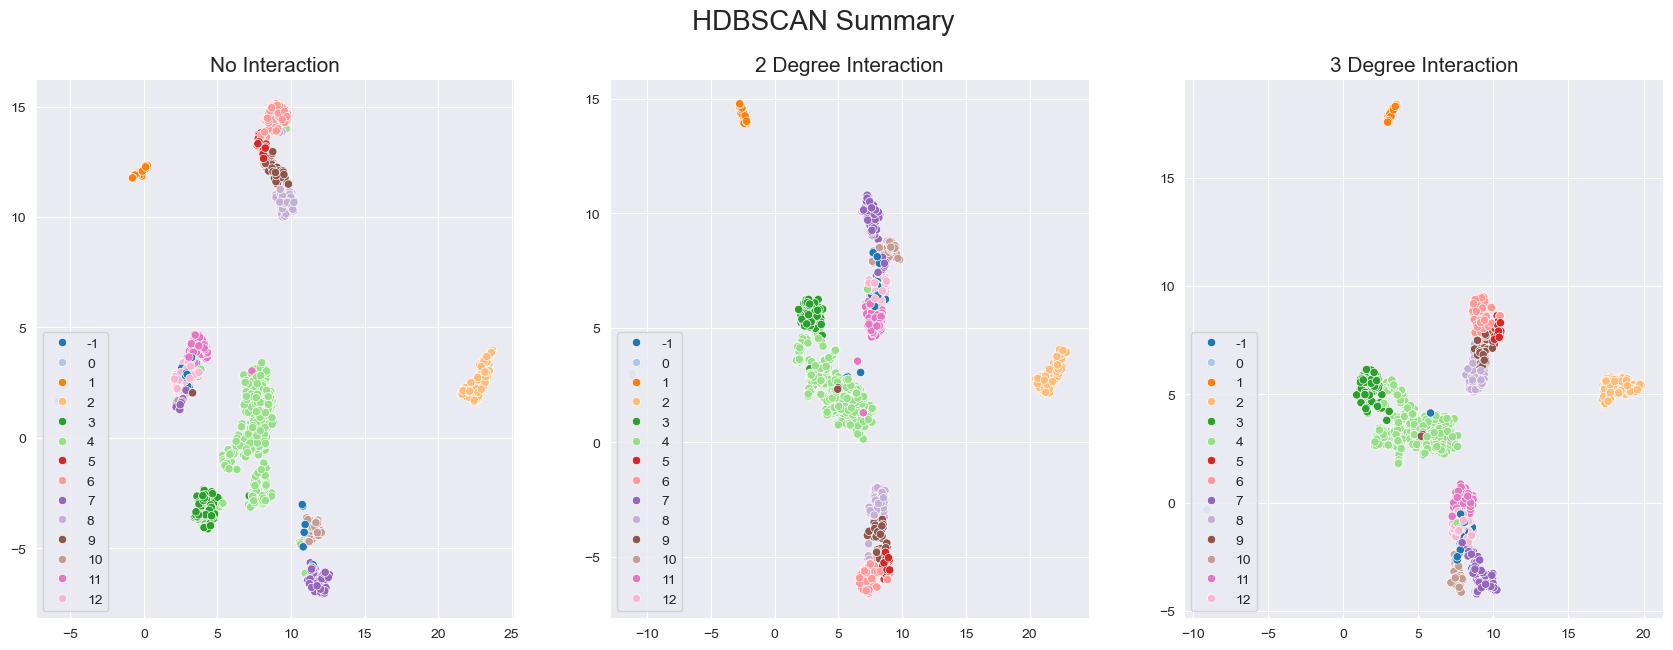

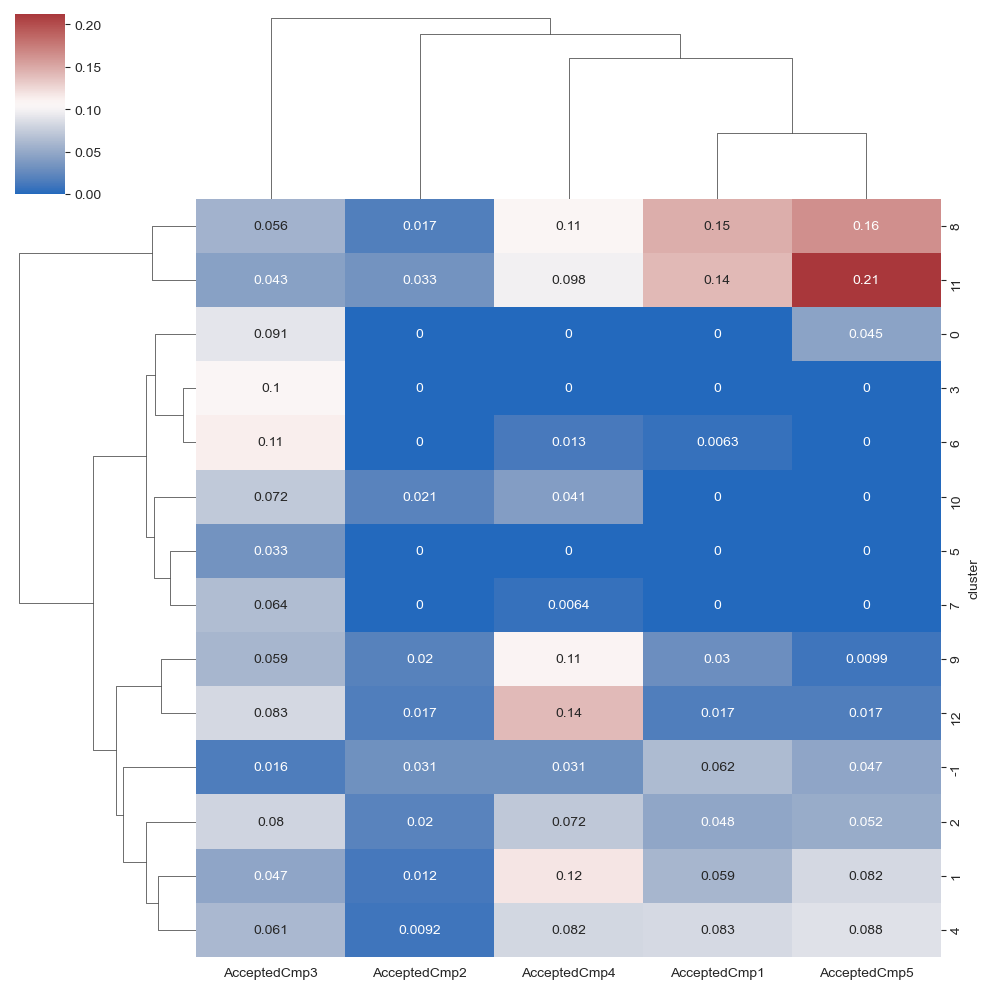

In [200]:
print('Campaigns and suggested clusters of HDBSCAN')
summary(hdb_pipe.set_params(**hdb_study.best_trial.params).fit_predict(sub_df),'HDBSCAN Summary')

### Spectral Clustering

In [170]:
sc_pipe = Pipeline([
    ('ss1',StandardScaler().set_output(transform='pandas')),
    ('poly',PolynomialFeatures().set_output(transform='pandas')),
    ('umap',umap.UMAP(random_state=seed)),
    ('sc',SpectralClustering(random_state=seed,n_jobs=-1))
])

def sc_params(trial):
    return {
        'poly__degree': trial.suggest_int('poly__degree',1,2),
        'umap__n_neighbors': trial.suggest_int('umap__n_neighbors', 5, 50),
        'umap__n_components': trial.suggest_int('umap__n_components', 2, 10),
        'umap__min_dist': trial.suggest_float('umap__min_dist', 0.01, 0.99),
        'umap__metric': trial.suggest_categorical('umap__metric', ['euclidean','cosine']),
        'sc__n_clusters': trial.suggest_int("sc__n_clusters", 10,15),
        'sc__n_components': trial.suggest_int('sc__n_components', 2, 10),
        'sc__affinity':trial.suggest_categorical('sc__affinity', ["rbf", "nearest_neighbors"]),
        'sc__gamma': trial.suggest_float('sc__gamma', 0.01, 10, log=True),
        'sc__n_neighbors': trial.suggest_int('sc__n_neighbors', 5, 50)
        }

sc_study,sc_model = cluster(sc_pipe,sc_params)

[I 2025-04-20 22:16:18,176] A new study created in memory with name: no-name-156a9908-37bd-453c-9859-7f1ad147b821
C:\Users\ACER\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:301: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.

[I 2025-04-20 22:16:25,828] Trial 0 finished with value: 0.43996956944465637 and parameters: {'poly__degree': 1, 'umap__n_neighbors': 48, 'umap__n_components': 8, 'umap__min_dist': 0.5966853145130959, 'umap__metric': 'euclidean', 'sc__n_clusters': 10, 'sc__n_components': 9, 'sc__affinity': 'nearest_neighbors', 'sc__gamma': 0.011527987128232402, 'sc__n_neighbors': 49}. Best is trial 0 with value: 0.43996956944465637.
[I 2025-04-20 22:16:32,552] Trial 1 finished with value: 0.4177255928516388 and parameters: {'poly__degree': 2, 'umap__n_neighb

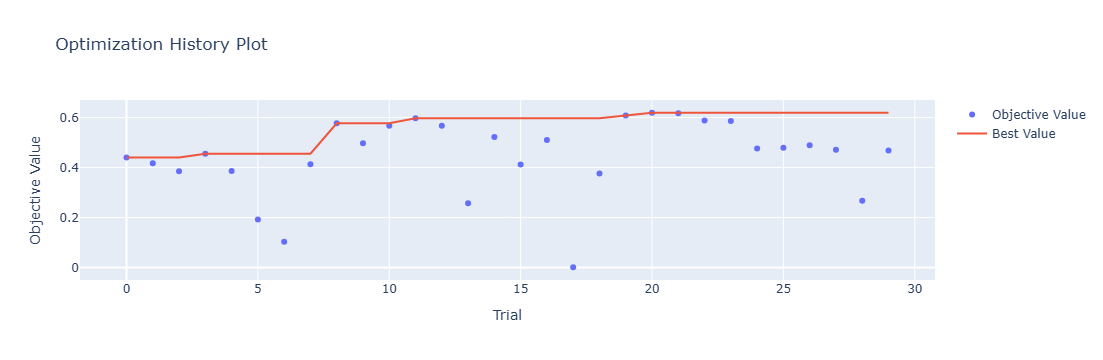

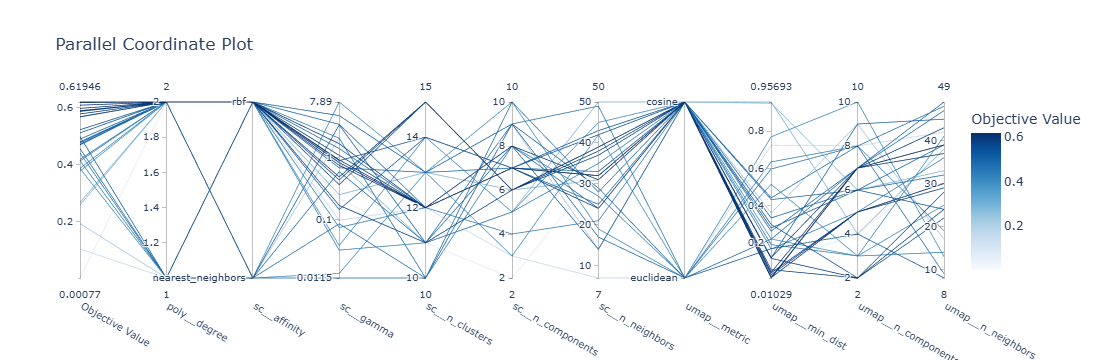

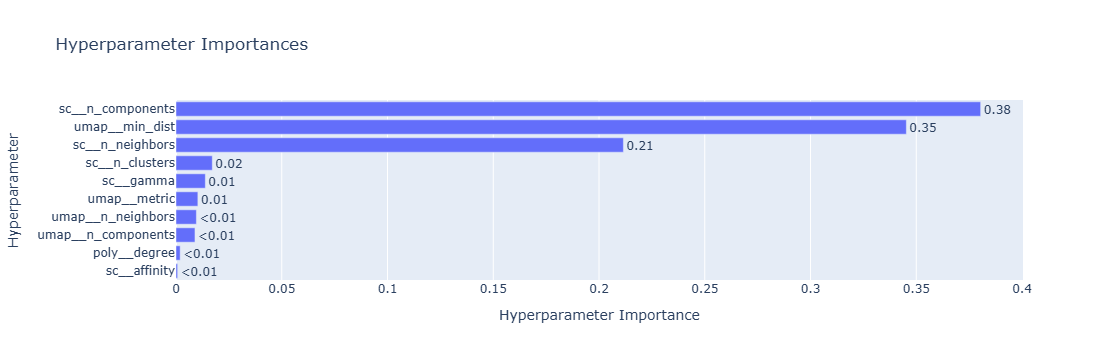

In [171]:
visualize(sc_study)

In [202]:
sc_study.best_trial.value

0.6194598078727722

In [172]:
sc_study.best_trial.params

{'poly__degree': 2,
 'umap__n_neighbors': 39,
 'umap__n_components': 7,
 'umap__min_dist': 0.010291734792165141,
 'umap__metric': 'cosine',
 'sc__n_clusters': 12,
 'sc__n_components': 7,
 'sc__affinity': 'rbf',
 'sc__gamma': 0.9206138163299464,
 'sc__n_neighbors': 32}

Campaigns and suggested clusters of Spectral Clustering


{'Campaign 1': [7, 8, 9],
 'Campaign 2': [],
 'Campaign 3': [],
 'Campaign 4': [3, 4, 7, 9, 11],
 'Campaign 5': [7, 8, 9]}

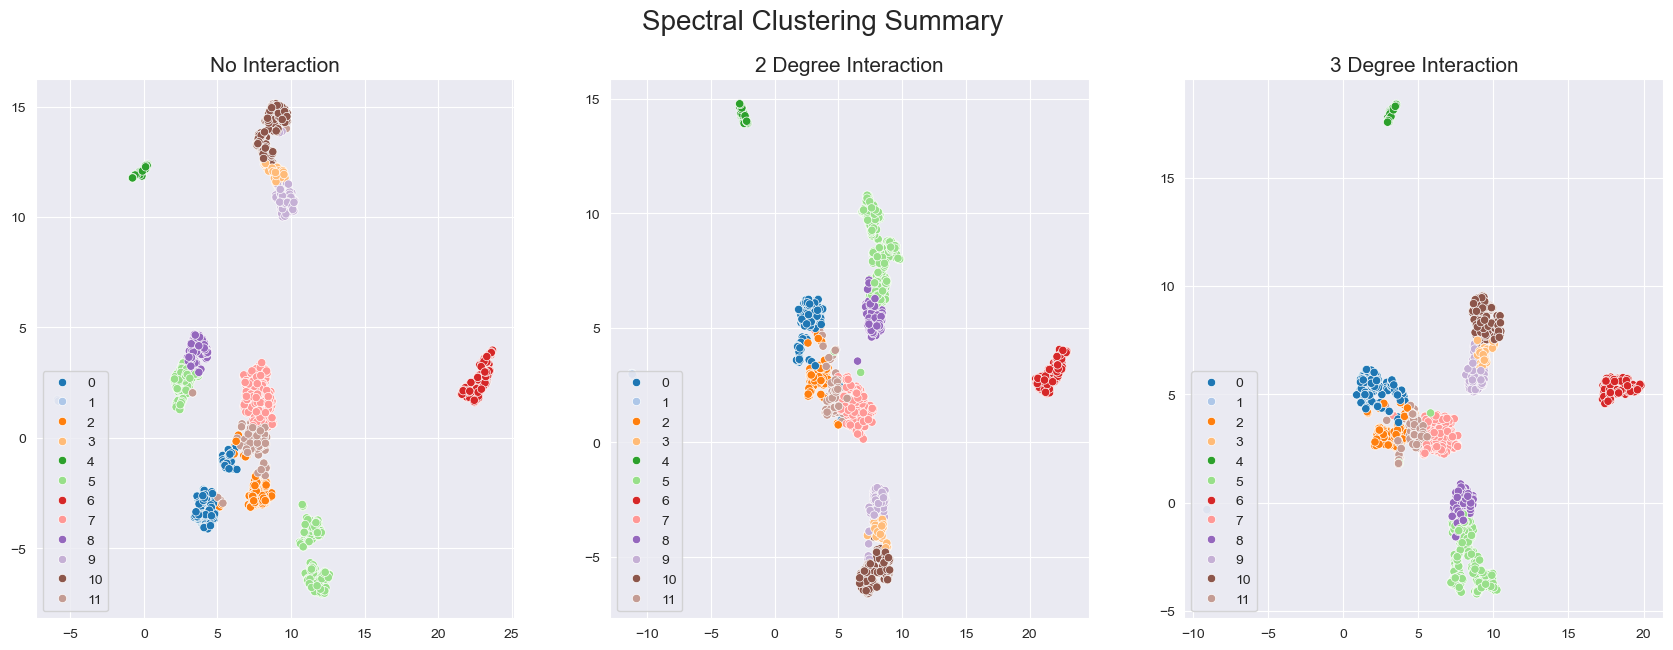

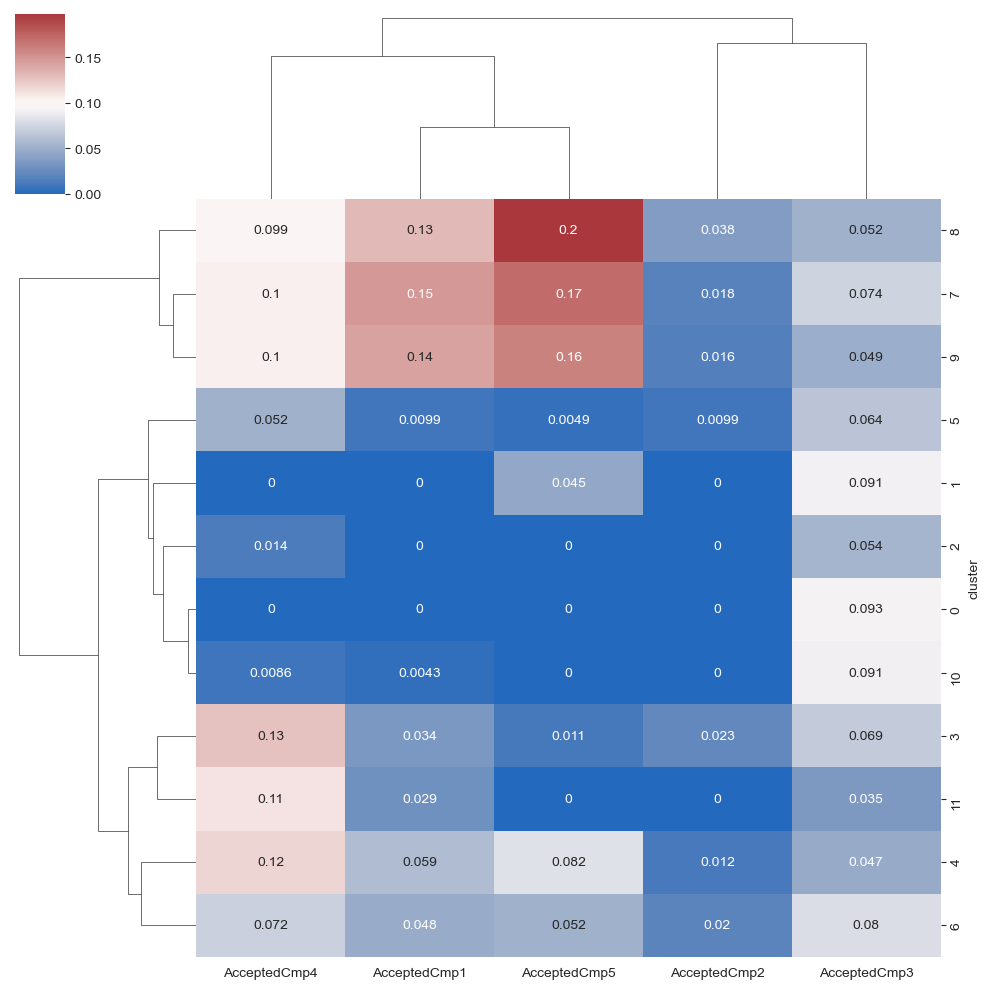

In [205]:
print('Campaigns and suggested clusters of Spectral Clustering')
summary(sc_model.fit_predict(sub_df),'Spectral Clustering Summary')

### Agglomerative CLustering

In [174]:
ac_pipe = Pipeline([
    ('ss1',StandardScaler().set_output(transform='pandas')),
    ('poly',PolynomialFeatures().set_output(transform='pandas')),
    ('umap',umap.UMAP(random_state=seed)),
    ('ac',AgglomerativeClustering())
])

def ac_params(trial):
    return {
            'poly__degree': trial.suggest_int('poly__degree',1,2),
            'umap__n_neighbors': trial.suggest_int('umap__n_neighbors', 5, 50),
            'umap__n_components': trial.suggest_int('umap__n_components', 2, 10),
            'umap__min_dist': trial.suggest_float('umap__min_dist', 0.01, 0.99),
            'umap__metric': trial.suggest_categorical('umap__metric', ['euclidean','cosine']),
            'ac__n_clusters': trial.suggest_int("ac__n_clusters", 10, 15),
            'ac__linkage': trial.suggest_categorical('ac__linkage',['ward', 'complete', 'average', 'single']),
        }

ac_study, ac_model = cluster(ac_pipe,ac_params)

[I 2025-04-20 22:20:26,764] A new study created in memory with name: no-name-f256cf53-69be-449d-97e5-b2fe5929d4a1
C:\Users\ACER\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

[I 2025-04-20 22:20:33,962] Trial 0 finished with value: 0.44174355268478394 and parameters: {'poly__degree': 1, 'umap__n_neighbors': 48, 'umap__n_components': 8, 'umap__min_dist': 0.5966853145130959, 'umap__metric': 'euclidean', 'ac__n_clusters': 10, 'ac__linkage': 'ward'}. Best is trial 0 with value: 0.44174355268478394.
[I 2025-04-20 22:20:41,373] Trial 1 finished with value: 0.5296058058738708 and parameters: {'poly__degree': 2, 'umap__n_neighbors': 43, 'umap__n_components': 3, 'umap__min_dist': 0.18818846786295862, 'umap__metric': 'cosine', 'ac__n_clusters': 13, 'ac__linkage': 'average'}. Best is trial 1 with value: 0.5296058058738708.
[I 2025-04-20 22:20:47,334] Trial 2 finished with value: 0.3748511373996734

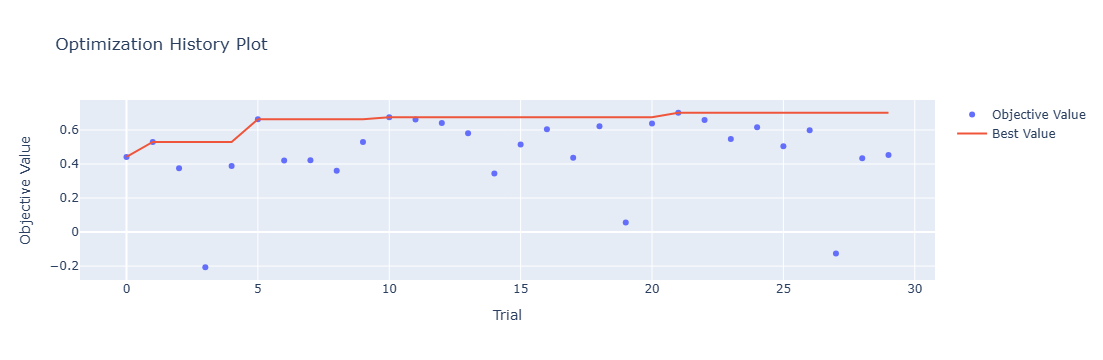

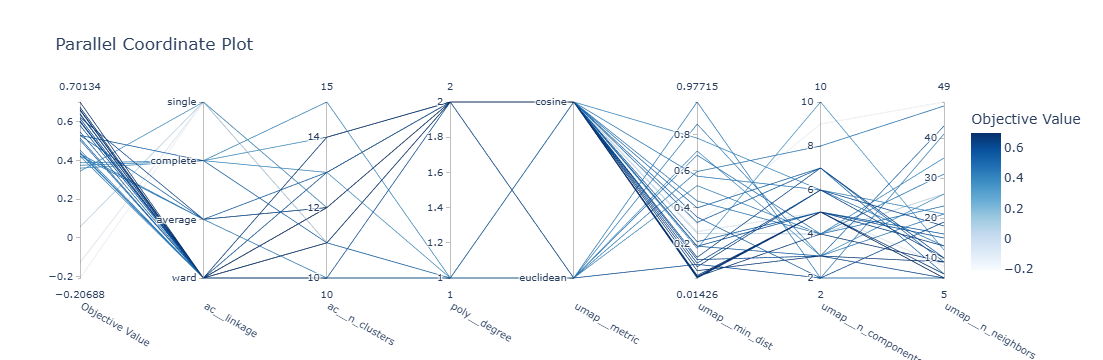

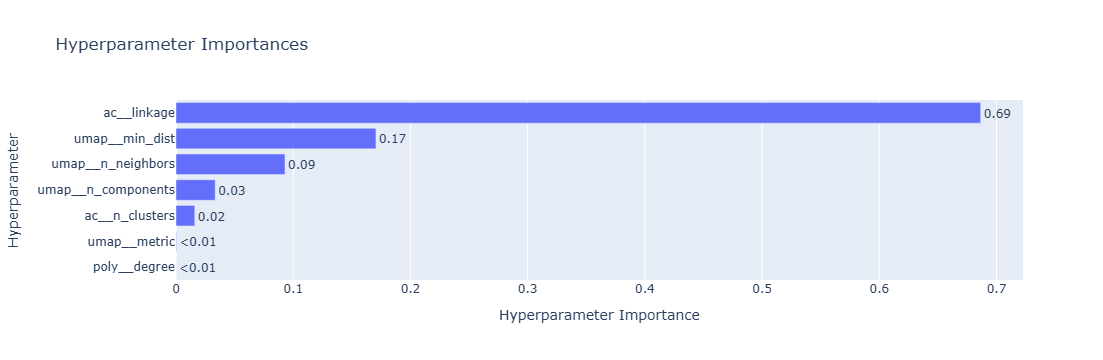

In [175]:
visualize(ac_study)

In [203]:
ac_study.best_trial.value

0.7013373374938965

In [176]:
ac_study.best_trial.params

{'poly__degree': 2,
 'umap__n_neighbors': 5,
 'umap__n_components': 5,
 'umap__min_dist': 0.021055690533401124,
 'umap__metric': 'cosine',
 'ac__n_clusters': 12,
 'ac__linkage': 'ward'}

Campaigns and suggested clusters of Agglomerative Clustering


{'Campaign 1': [2, 8],
 'Campaign 2': [],
 'Campaign 3': [5],
 'Campaign 4': [1, 2, 7],
 'Campaign 5': [1, 2, 8]}

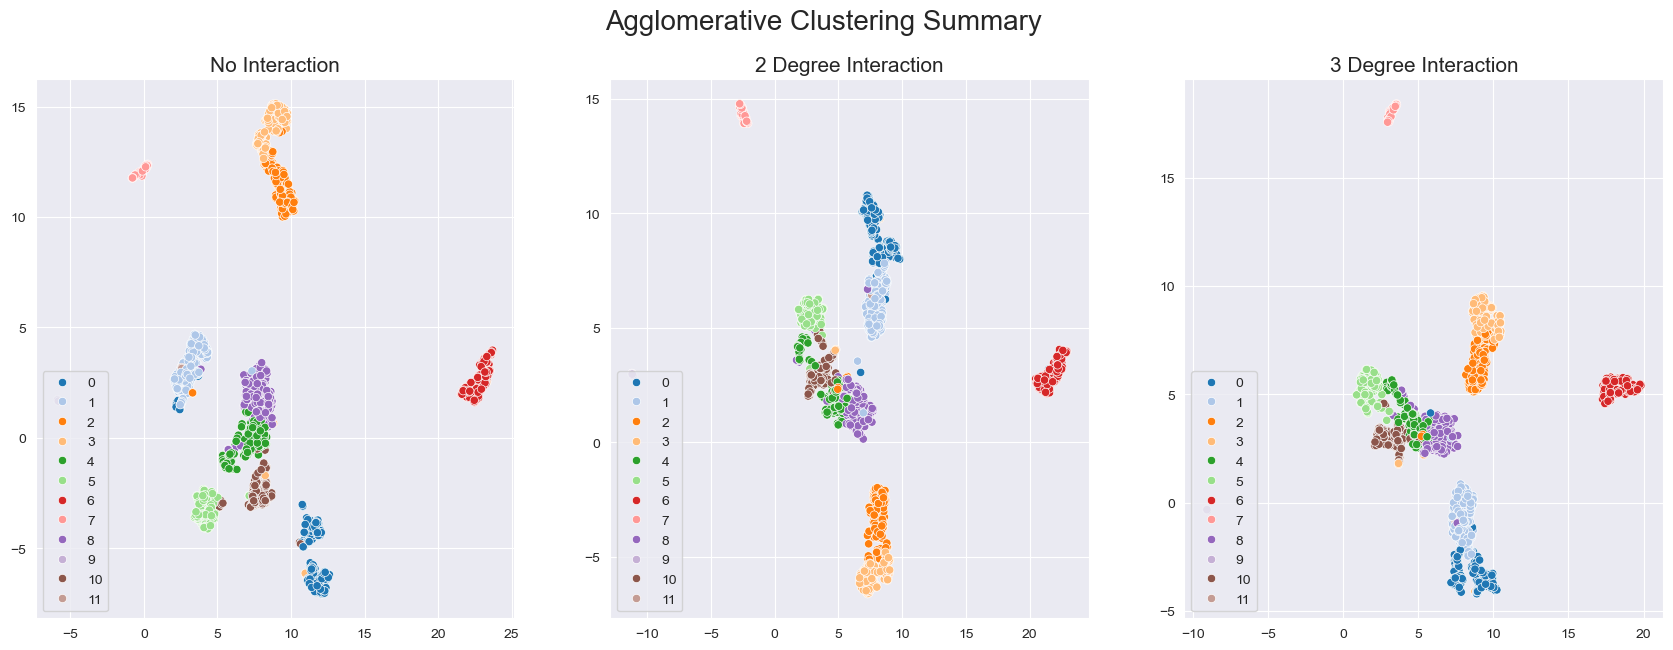

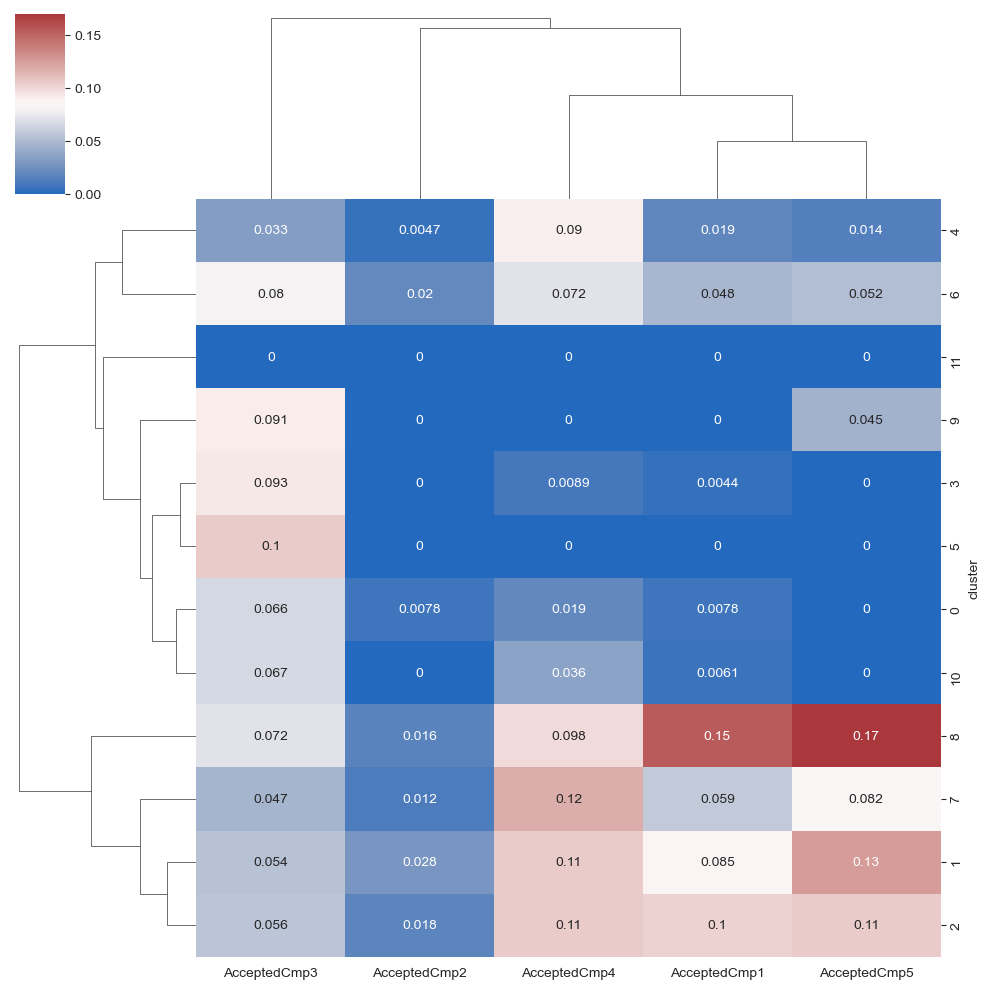

In [204]:
print('Campaigns and suggested clusters of Agglomerative Clustering')
summary(ac_model.fit_predict(sub_df),'Agglomerative Clustering Summary')